## Модель предсказания вероятности клика (CTR) на рекламу

## Постановка задачи и требования

### Задача:
- построить модель бинарной классификации, которая предсказывает вероятность клика (CTR) на рекламное объявление.

### Требования:

Калибровка:
- предсказанные вероятности кликов должны максимально точно соответствовать и их реальной частоте 

Метрики:
- PR-AUC — основная метрика. Она наиболее адекватно оценивает качество модели на несбалансированных данных. Клики — это более редкое событие, чем пропуск рекламы
- Log Loss позволит оценить точность предсказанных вероятностей. 
- Оценка Бриера измеряет и точность, и калибровку модели



## 1. Подготовка среды и загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import average_precision_score
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import cross_validate
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
import joblib
from sklearn.preprocessing import TargetEncoder
from scipy import sparse
from sklearn.feature_selection import RFE

In [44]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [45]:
# загрузка данных
df = pd.read_csv('https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv')

In [46]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

## 2. Исследовательский анализ данных (EDA)

### 2.1 Базовая информация 

In [48]:
df.shape

(50000, 34)

In [49]:
df.isna().sum().sum()  # явных пропусков нет

np.int64(0)

In [ ]:
cat_cols_types = ['object']
cat_cols = df.select_dtypes(include=cat_cols_types).columns
num_cols = df.select_dtypes(include=['int', 'float']).columns
cat_cols, len(cat_cols), num_cols, len(num_cols)

(Index(['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain',
        'app_category', 'device_id', 'device_ip', 'device_model',
        'ml_feature_2', 'ml_feature_7'],
       dtype='object'),
 11,
 Index(['id', 'click', 'hour', 'C1', 'banner_pos', 'device_type',
        'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20',
        'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
        'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'],
       dtype='object'),
 23)

#### Датасет:

- 50000 объектов
- 33 признака и целевая переменная 
- 11 категориальных и 22 числовых признака, целевая переменная в виде числа
- данные не содержат явных пропусков

#### Пользователи и реклама:

Идентификаторы и временные метки:
- id — уникальный идентификатор записи о показе баннера;
- hour — час, в который был показан баннер, в формате YYMMDDHH.

Характеристики рекламной площадки ( Site ):
- site_id — идентификатор веб-сайта, на котором был показан баннер;
- site_domain — домен веб-сайта;
- site_category — тематическая категория веб-сайта.

Характеристики рекламируемого приложения ( App ):
- app_id — идентификатор рекламируемого мобильного приложения;
- app_domain — домен рекламируемого приложения;
- app_category — категория рекламируемого приложения.

Характеристики устройства и соединения пользователя:
- device_id — идентификатор браузера или устройства;
- device_ip — IP-адрес устройства;
- device_model — модель устройства;
- device_type — тип устройства пользователя: например, смартфон, планшет, ПК;
- device_conn_type — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

Характеристики рекламного баннера и аукциона:
- C1 — анонимизированный признак, характеризующий контекст показа;
- banner_pos — позиция баннера на веб-странице;
- C14 — C21 — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

Машинно-сгенерированные признаки (ML Features):
- ml_feature_1, ml_feature_3 — ml_feature_6, ml_feature_8 — ml_feature_10 — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;
- ml_feature_2, ml_feature_7 — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

Целевая переменная:
- click — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.



---

### 2.2 Анализ целевой переменной

In [51]:
target = df['click']

In [52]:
# Соотношение классов
target.value_counts() / len(target) * 100

click
0    82.794
1    17.206
Name: count, dtype: float64

Анализ:
- среди классов наблюдается дисбаланс: 83% пропусков рекламы, 17% кликов

Рекомендация:
- при разделениий на выброки необходимо применять стратификацию

---

### 2.3 Анализ признаков

#### Категориальные признаки

#### Преобразование количественных признаков, по смыслу являюшихся категориальными

In [53]:
extra_cat_feat = ['device_type', 'device_conn_type', 'ml_feature_4', 'C18', 'banner_pos']  # признаки, по смыслу явяющиеся категориальнымм  
df[extra_cat_feat] = df[extra_cat_feat].astype(str)
df[extra_cat_feat].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   device_type       50000 non-null  object
 1   device_conn_type  50000 non-null  object
 2   ml_feature_4      50000 non-null  object
 3   C18               50000 non-null  object
 4   banner_pos        50000 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


In [54]:
cat_cols = df.select_dtypes(include=cat_cols_types).columns
df[cat_cols].nunique()

banner_pos              7
site_id              1160
site_domain          1013
site_category          18
app_id                976
app_domain             67
app_category           22
device_id            8580
device_ip           41455
device_model         2521
device_type             4
device_conn_type        4
C18                     4
ml_feature_2            5
ml_feature_4            2
ml_feature_7            3
dtype: int64

Анализ:
- уникальных значений для site_id, site_domain, app_id, device_id, device_ip, device_model довольно много (>900). Среди этих признаков имеются техническими данные, связянными со сбором информации. Кандиданты на удаление.
- проведем визуальных анализ распределения целевого класса среди категориальных признаков, где уникальных значений немного (<100).

#### Соотношение целевых классов внутри признаков

In [55]:
# для категориальных признаков cat_cols строим столбчатые диаграммы

def plot_bar_target_class(df: pd.DataFrame, target_name: str, cat_col: str):

    df_chain_unstack = df.groupby(cat_col)[target_name].value_counts(normalize=True).unstack(fill_value=0).sort_values(by=1)

    df_chain_unstack.plot(kind='bar', figsize=(10, 6),)

    plt.title(f'Доля целевых классов для признака {cat_col}') 
    plt.ylabel('Доля') 
    plt.xlabel(cat_col) 
    plt.xticks(rotation=45)  
    plt.legend()  

    plt.show()

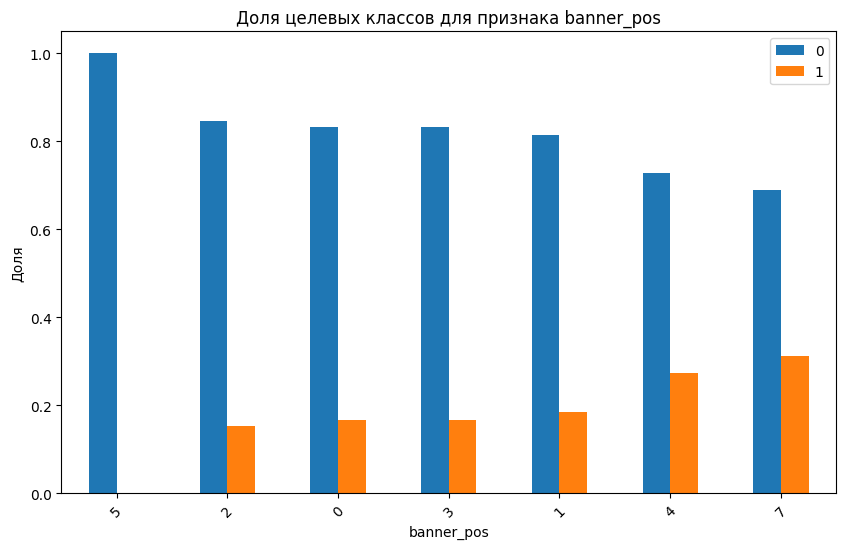

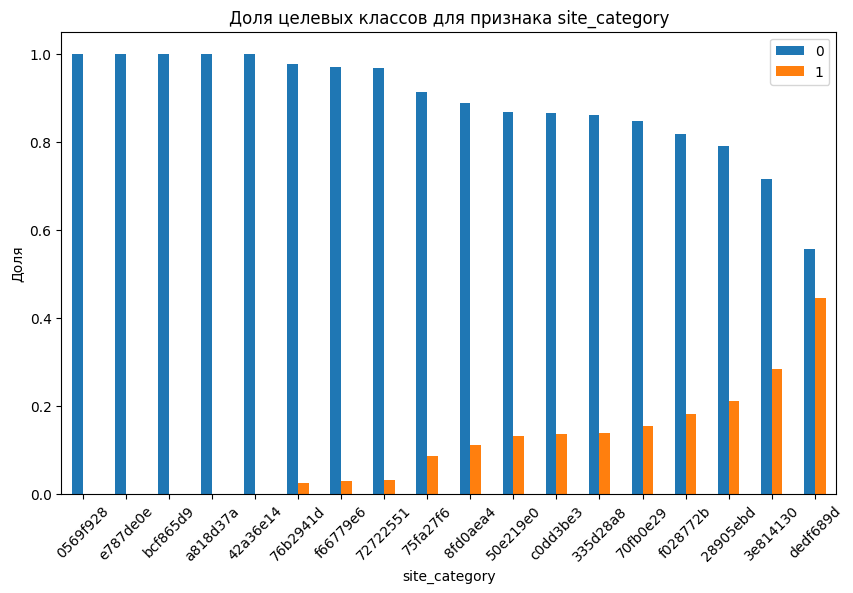

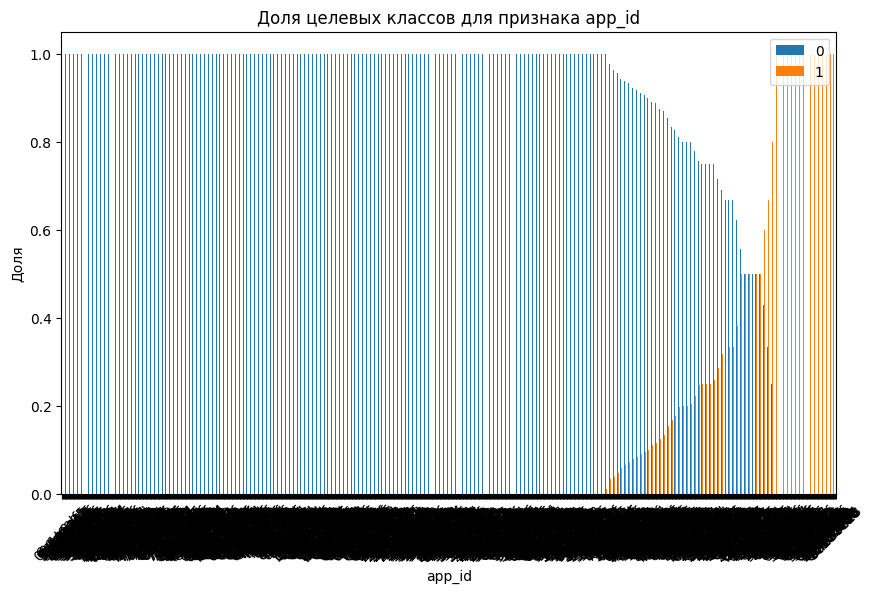

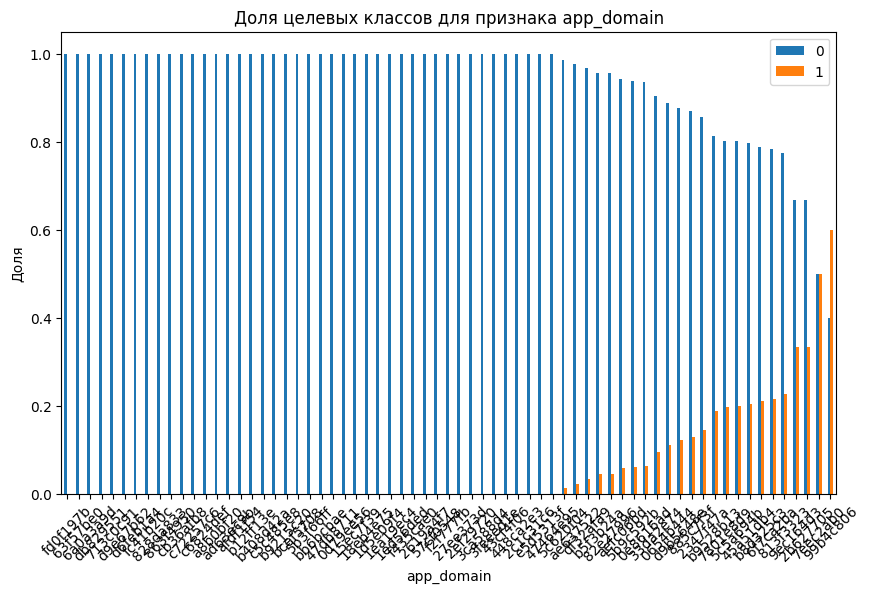

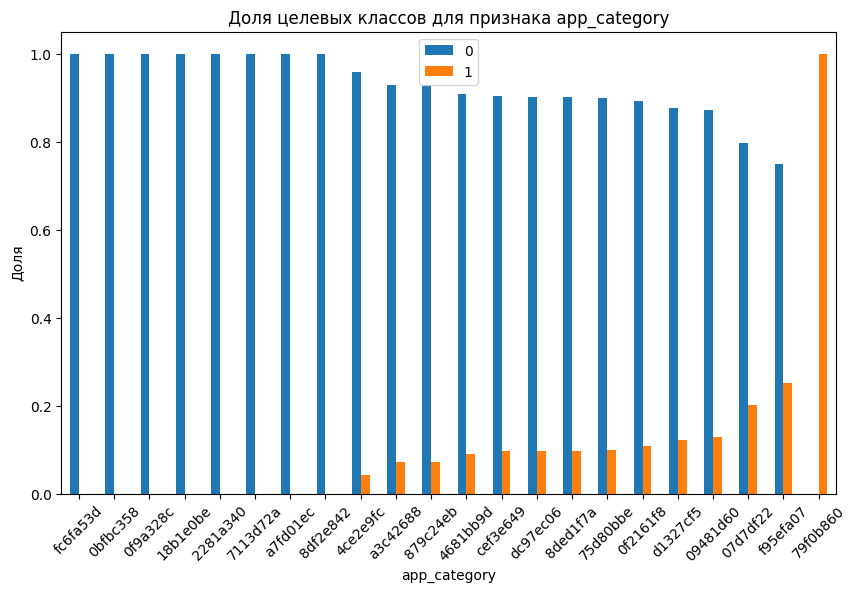

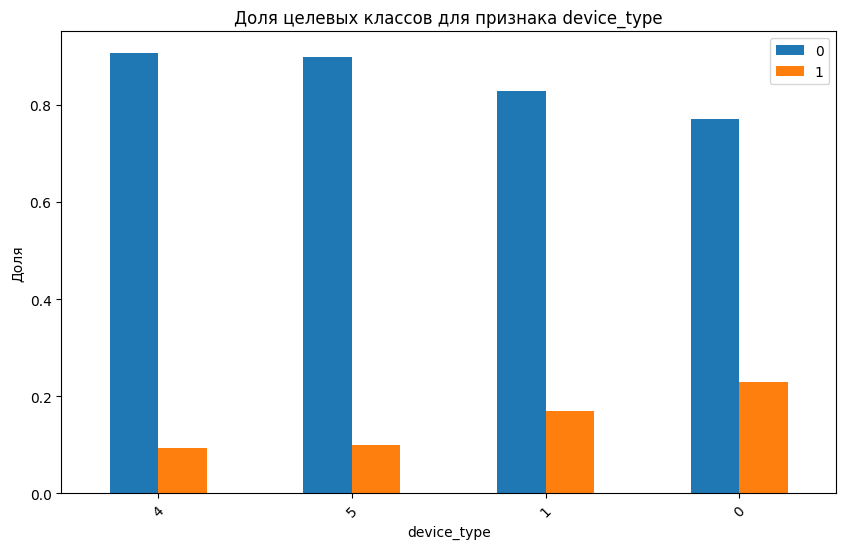

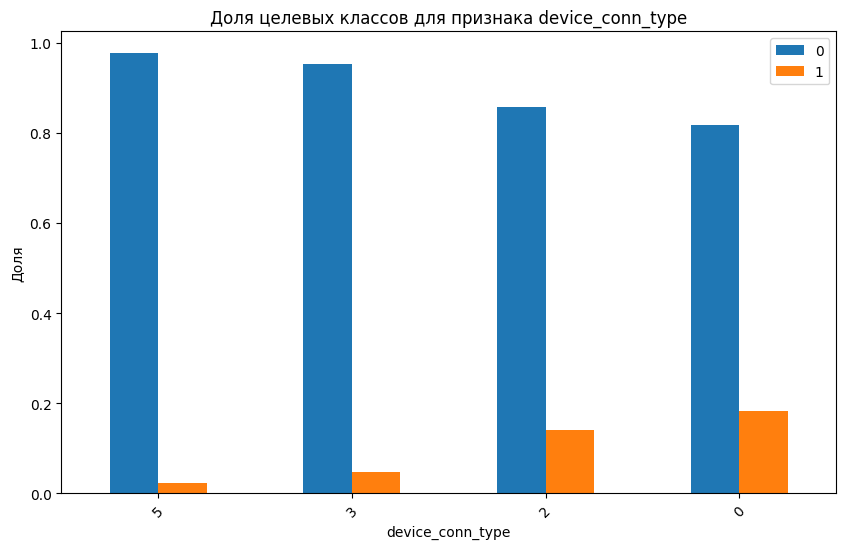

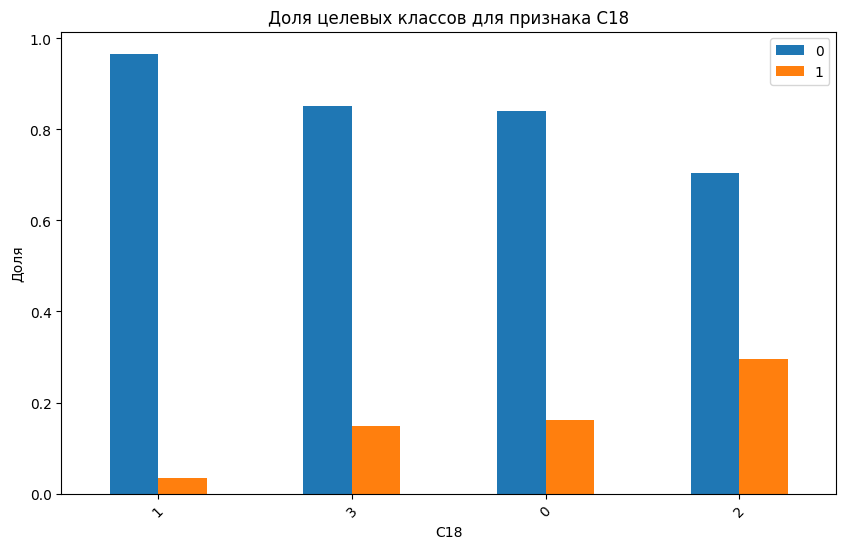

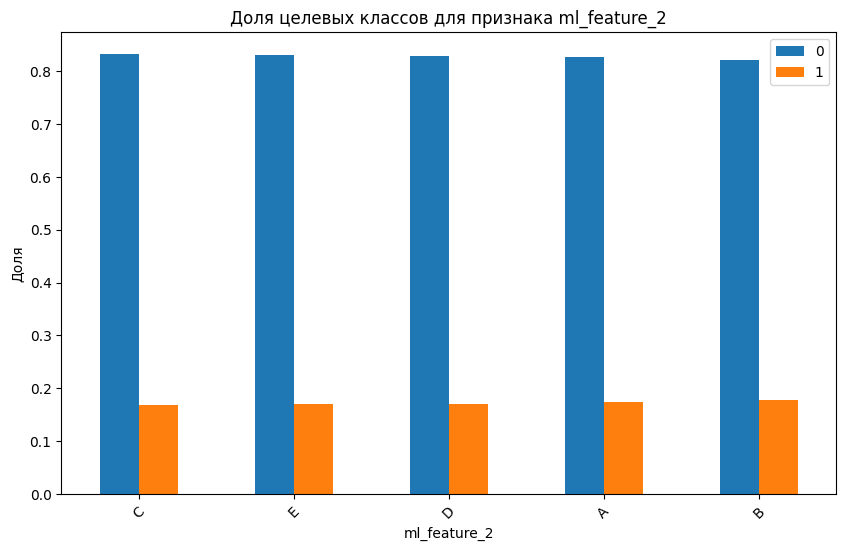

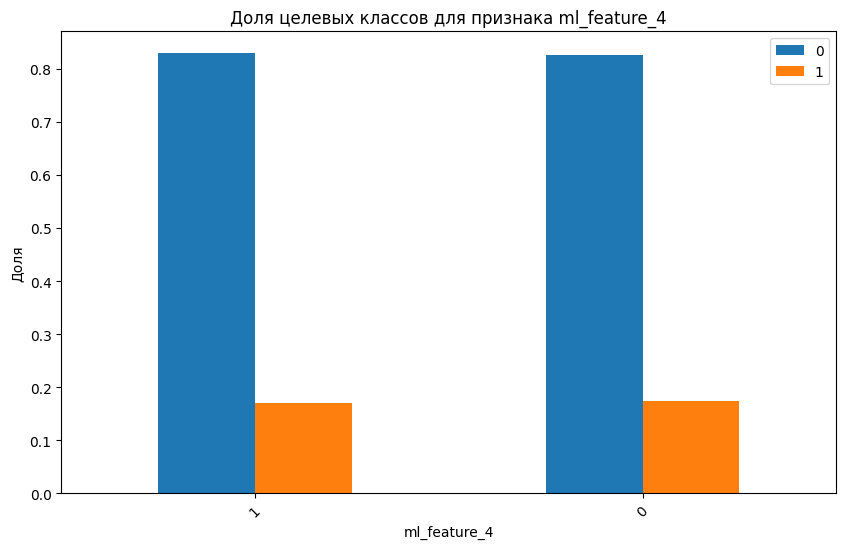

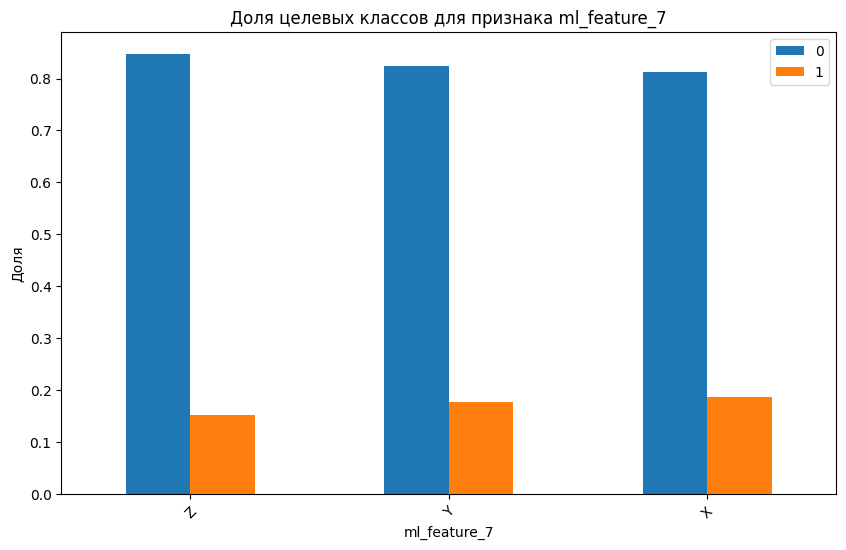

In [56]:
cat_cols_to_analyze = df[cat_cols].nunique()[df[cat_cols].nunique() < 1000].index.tolist()

for name in cat_cols_to_analyze:
    plot_bar_target_class(df=df, target_name='click', cat_col=name)

Анализ:
- доля целевых классов внутри признаков ml_feature_7, ml_feature_2 практически не отличается
- для признаков 'site_category', 'app_domain', 'app_category', 'device_*', 'C18' есть существенные различия по долям целевого класса

Рекомендация:
- ml_feature_7, ml_feature_2 - кандидаты на удаление, поскольку их связь с целевой переменной минимальна

In [57]:
cat_cols

Index(['banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id',
       'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model',
       'device_type', 'device_conn_type', 'C18', 'ml_feature_2',
       'ml_feature_4', 'ml_feature_7'],
      dtype='object')

In [58]:
def get_corr_matrix(
    data: pd.DataFrame, feat_cols: list[str], 
    num_cols: list[str], target_col_name: str, 
):
    corr_matrix = data[feat_cols].phik_matrix(
        interval_cols=num_cols if len(num_cols) > 0 else None,
        njobs=1,
    )

    return corr_matrix


In [59]:
def get_target_corr(
        data: pd.DataFrame, feat_cols: list[str], 
        num_cols: list[str], target_col_name: str, 
        plot_corr_matrix: bool = True
):
    corr_matrix = get_corr_matrix(data, feat_cols, num_cols, target_col_name)

    if plot_corr_matrix:
        plt.figure(figsize=(14, 10)) 

        sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

        plt.title('Тепловая карта матрицы корреляций')
        plt.show()
    return corr_matrix[target_col_name].sort_values(ascending=False)

interval columns not set, guessing: ['click']


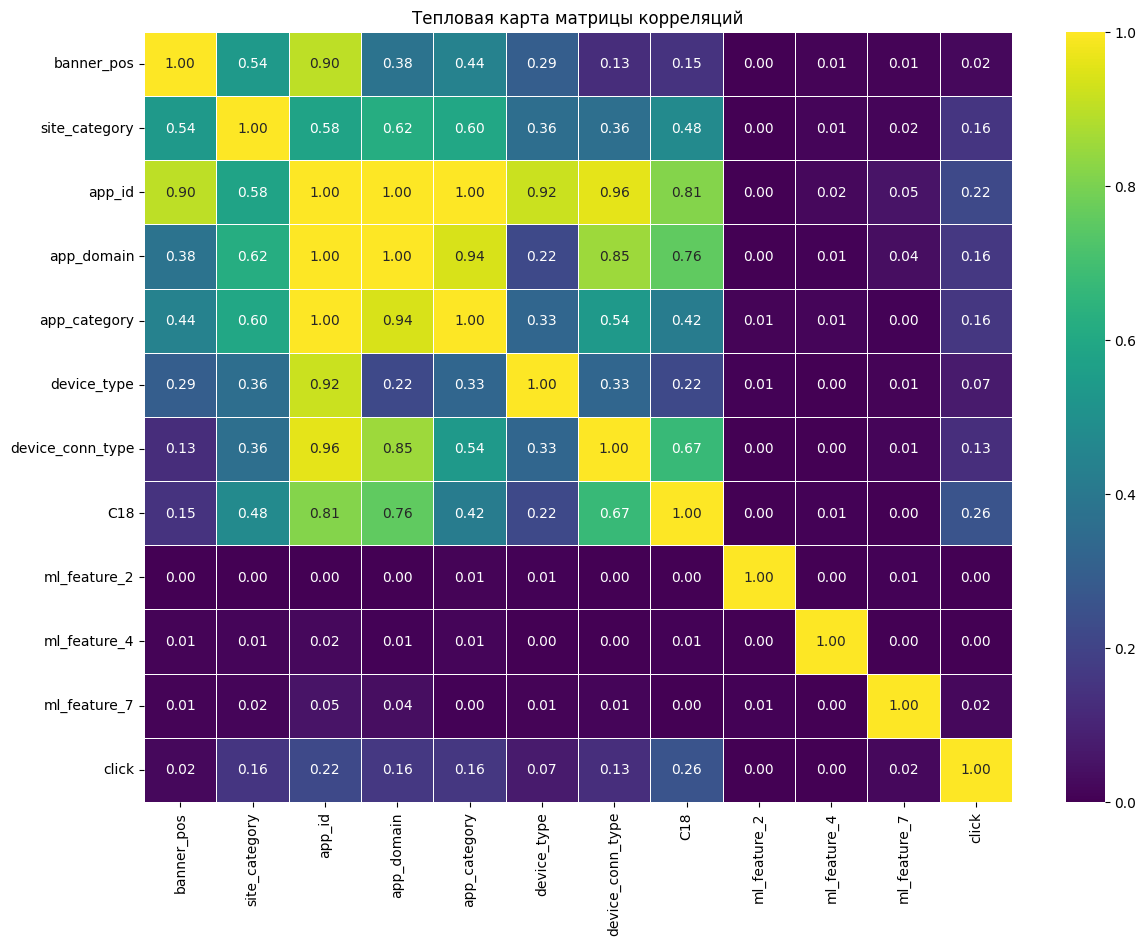

click               1.000000
C18                 0.257840
app_id              0.221436
app_domain          0.161289
app_category        0.156537
site_category       0.155008
device_conn_type    0.129954
device_type         0.071790
ml_feature_7        0.022622
banner_pos          0.022605
ml_feature_2        0.003790
ml_feature_4        0.000000
Name: click, dtype: float64

In [60]:
# Посчитаем матрицу корреляций для категорий, где количество уникальных значений позволяет это сделать

corr_with_target_cat = get_target_corr(df, cat_cols_to_analyze + ['click'], [], target_col_name='click')
corr_with_target_cat

Анализ:
- высокая корреляция (от 0.94 и до 1) между признаками: app_id, app_domain, app_category, device_conn_type. Для избежания проблемы мультиколлинеарности стоит оставить только один из них. Можно оставить наиболее скоррелированный с целевой переменной
-  наиболее связан с click признак C18: 0.26
- наименее связанные признаки с click: 
    - ml_feature_7:     0.022622
    - ml_feature_2:     0.003790

#### Кодирование категориальных признаков

- признаки, для которых уникальных значений <10 будем кодировать OneHotEncoder
- признаки с большим кол-вом уникальных значений будем кодировать с помощью TargetEncoding, чтобы не раздувать размерность задачи

In [61]:
cat_nunique = df[cat_cols].nunique()
one_hot_code_cols = cat_nunique[cat_nunique < 10]

print('кандидаты для кодирования OneHot: ')
one_hot_code_cols

кандидаты для кодирования OneHot: 


banner_pos          7
device_type         4
device_conn_type    4
C18                 4
ml_feature_2        5
ml_feature_4        2
ml_feature_7        3
dtype: int64

In [62]:
target_code_cols = cat_nunique[cat_nunique > 10]

print('кандидаты для кодирования TargetEncoder: ')
target_code_cols

кандидаты для кодирования TargetEncoder: 


site_id           1160
site_domain       1013
site_category       18
app_id             976
app_domain          67
app_category        22
device_id         8580
device_ip        41455
device_model      2521
dtype: int64

---
#### Количественные признаки

In [63]:
df[num_cols].head()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,1,0,17614,320,50,...,-1,33,-0.996823,0.666588,0,0.817292,0.993275,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1,0,15701,320,50,...,-1,79,-0.391309,5.146789,1,-0.883865,-0.825722,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,1,0,17914,320,50,...,100084,32,-2.112732,7.169348,0,-0.859440,-0.338365,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,1,0,21611,320,50,...,100111,61,0.332707,-0.290708,1,0.062795,0.062934,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1,0,15702,320,50,...,100084,79,1.166623,6.319134,1,-0.675276,0.797144,0.640827,0.297955,-0.136909


- данные содержат признак hours в формате YYMMDDHH и типа int. Этот признак стоит преобразовать

#### Преобразование признака hours

In [64]:
# преобразуем hour в формат даты
hour_str = df['hour'].astype(str).str.zfill(8)
dt_format = pd.to_datetime(hour_str, format="%y%m%d%H")

# 
df['hour_of_day'] = dt_format.dt.hour
df['day'] = dt_format.dt.day
df['month'] = dt_format.dt.month
df['year'] = dt_format.dt.year

# циклические признаки (чтобы 23ч и 0ч воспринимались, как близкие значения)
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)

df = df.drop(columns=['hour'])

In [65]:
df.head()

,id,click,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,...,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10,hour_of_day,day,month,year,hour_sin,hour_cos
0,1.005263e+19,1,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,...,Z,-0.619959,0.433666,0.274038,0,21,10,2014,0.0,1.0
1,1.010597e+19,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,X,0.576526,-0.318558,-0.132851,0,21,10,2014,0.0,1.0
2,1.012048e+19,0,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,...,Y,-0.440047,-0.345412,0.340487,0,21,10,2014,0.0,1.0
3,1.021995e+18,0,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,...,Y,0.551982,0.733382,-0.198542,0,21,10,2014,0.0,1.0
4,1.023455e+19,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,X,0.640827,0.297955,-0.136909,0,21,10,2014,0.0,1.0


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   C1                50000 non-null  int64  
 3   banner_pos        50000 non-null  object 
 4   site_id           50000 non-null  object 
 5   site_domain       50000 non-null  object 
 6   site_category     50000 non-null  object 
 7   app_id            50000 non-null  object 
 8   app_domain        50000 non-null  object 
 9   app_category      50000 non-null  object 
 10  device_id         50000 non-null  object 
 11  device_ip         50000 non-null  object 
 12  device_model      50000 non-null  object 
 13  device_type       50000 non-null  object 
 14  device_conn_type  50000 non-null  object 
 15  C14               50000 non-null  int64  
 16  C15               50000 non-null  int64 

In [67]:
# обновляем значение категориальных и числовых признаков
cat_cols = df.select_dtypes(include=cat_cols_types).columns
num_cols = df.select_dtypes(include=['int', 'float']).columns
cat_cols, len(cat_cols), num_cols, len(num_cols)

(Index(['banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id',
        'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model',
        'device_type', 'device_conn_type', 'C18', 'ml_feature_2',
        'ml_feature_4', 'ml_feature_7'],
       dtype='object'),
 16,
 Index(['id', 'click', 'C1', 'C14', 'C15', 'C16', 'C17', 'C19', 'C20', 'C21',
        'ml_feature_1', 'ml_feature_3', 'ml_feature_5', 'ml_feature_6',
        'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'hour_of_day', 'day',
        'month', 'year', 'hour_sin', 'hour_cos'],
       dtype='object'),
 23)

In [68]:
df[num_cols].describe()

,id,click,C1,C14,C15,C16,C17,C19,C20,C21,...,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10,hour_of_day,day,month,year,hour_sin,hour_cos
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.0,5.000000e+04,50000.000000
mean,9.215402e+18,0.172060,1004.970060,18826.648680,318.86640,59.692480,2109.781020,227.703800,53173.383240,83.685180,...,0.022948,0.025465,0.035361,0.020226,11.221500,25.478220,10.0,2014.0,4.729782e-02,-0.198552
std,5.328516e+18,0.377436,1.110202,4983.064178,20.56153,46.720842,612.963141,351.592108,49960.181871,70.539513,...,0.656690,0.578026,0.505034,0.303309,5.938008,2.964945,0.0,0.0,7.194056e-01,0.663939
min,3.191077e+13,0.000000,1001.000000,375.000000,120.00000,20.000000,112.000000,33.000000,-1.000000,13.000000,...,-1.000000,-0.999965,-2.147526,-1.287965,0.000000,21.000000,10.0,2014.0,-1.000000e+00,-1.000000
25%,4.580649e+18,0.000000,1005.000000,16920.000000,320.00000,50.000000,1823.000000,35.000000,-1.000000,23.000000,...,-0.579775,-0.470627,-0.304077,-0.182386,6.000000,23.000000,10.0,2014.0,-7.071068e-01,-0.866025
50%,9.243015e+18,0.000000,1005.000000,20346.000000,320.00000,50.000000,2323.000000,39.000000,100049.000000,61.000000,...,0.037786,0.027348,0.035985,0.018930,11.000000,26.000000,10.0,2014.0,1.224647e-16,-0.258819
75%,1.380920e+19,0.000000,1005.000000,21916.000000,320.00000,50.000000,2526.000000,171.000000,100094.000000,108.000000,...,0.637131,0.521117,0.374152,0.224080,16.000000,28.000000,10.0,2014.0,7.071068e-01,0.500000
max,1.844652e+19,1.000000,1012.000000,24043.000000,1024.00000,1024.000000,2757.000000,1839.000000,100248.000000,255.000000,...,1.000000,1.119858,2.120786,1.202300,23.000000,30.000000,10.0,2014.0,1.000000e+00,1.000000


#### корреляционный анализ

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable month for analysis 1. Dropping this column
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable year for analysis 1. Dropping this column
  warnings.warn(


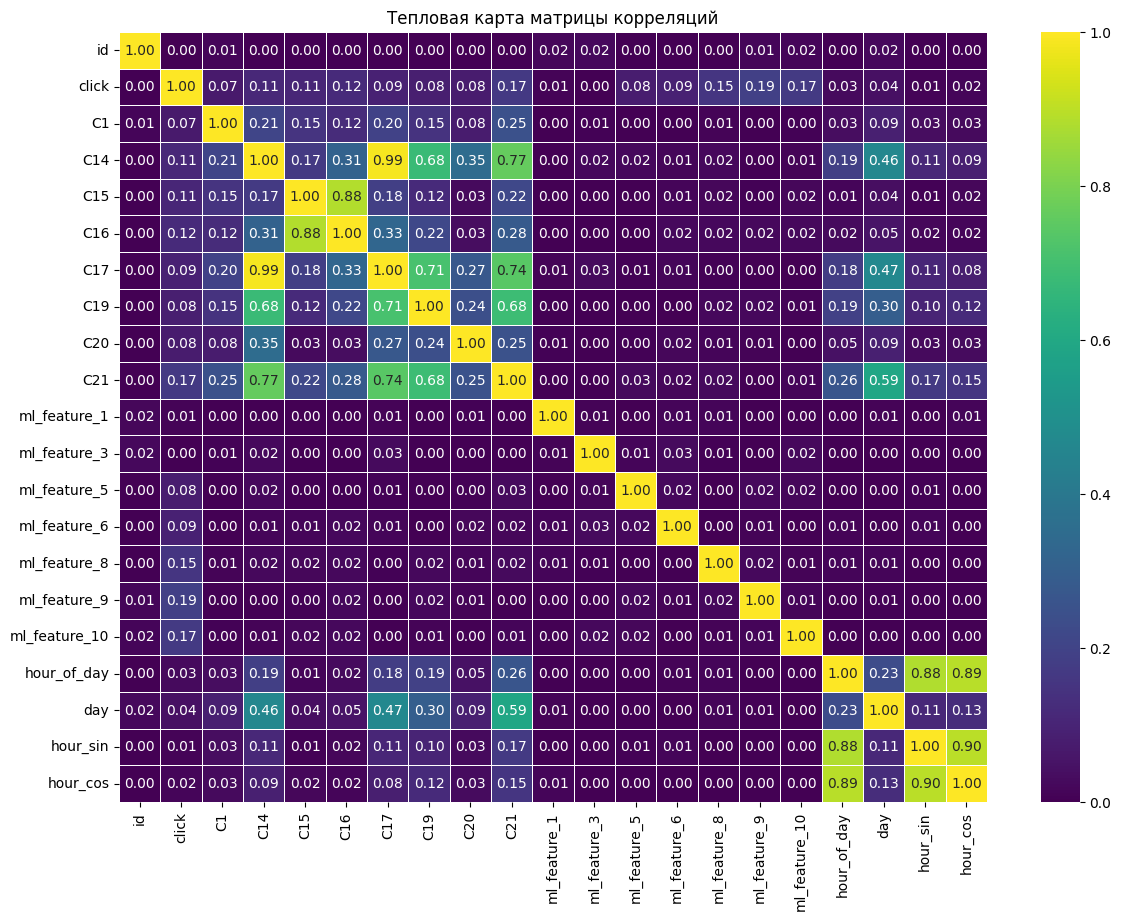

In [69]:
corr_with_target_num = get_target_corr(df, num_cols, num_cols, target_col_name='click')


In [70]:
top_n = 10

print(f'Топ {top_n} по корреляции с целевой переменной:')
corr_with_target_num[:top_n], corr_with_target_num[:top_n].index

Топ 10 по корреляции с целевой переменной:


(click            1.000000
 ml_feature_9     0.187801
 ml_feature_10    0.169983
 C21              0.166235
 ml_feature_8     0.153598
 C16              0.117539
 C14              0.112890
 C15              0.106817
 ml_feature_6     0.091314
 C17              0.091306
 Name: click, dtype: float64,
 Index(['click', 'ml_feature_9', 'ml_feature_10', 'C21', 'ml_feature_8', 'C16',
        'C14', 'C15', 'ml_feature_6', 'C17'],
       dtype='object'))

In [71]:
last_n = 10

print(f'Наименее скореллированные с целевой переменной {last_n} признаков:')
corr_with_target_num[-last_n:], corr_with_target_num[-last_n:].index

Наименее скореллированные с целевой переменной 10 признаков:


(ml_feature_5    0.080014
 C20             0.075979
 C1              0.067731
 day             0.042935
 hour_of_day     0.025113
 hour_cos        0.015225
 ml_feature_1    0.010056
 hour_sin        0.009241
 ml_feature_3    0.000000
 id              0.000000
 Name: click, dtype: float64,
 Index(['ml_feature_5', 'C20', 'C1', 'day', 'hour_of_day', 'hour_cos',
        'ml_feature_1', 'hour_sin', 'ml_feature_3', 'id'],
       dtype='object'))

Анализ:
- высокие коэффициенты корреляции:
    - C14, C17 -  0.99
    - C1, device_type - 0.92
    - C15, C16 - 0.88
    - hours_sin, hours_cos - 0.9

- наиболее скоррелированные признаки с целевой переменной (их точно стоит оставить): 
    - 'ml_feature_9', 'ml_feature_10', 'C21', 'ml_feature_8', 'C16', 'C14', 'C15', 'ml_feature_6', 'C17'
- наименее скорреированные с целевой переменной (кандидаты на удаление):
    - 'ml_feature_5', 'C20', 'C1', 'day', 'hour_of_day', 'hour_cos', 'ml_feature_1', 'hour_sin', 'ml_feature_3', 'id'

Рекомендация:
- для избежания проблемы мультиколлинеарности стоит рассмотреть удаление одного признака из пары сильно скоррлированных 
- мало скоррелированные признаки с целевой переменной стоит рассмотреть к удалению
- после разбиение на train/test можно еще раз взглянуть на корреляции этих признаков и удалить высоко скоррелированные между собой

### Анализ распределений

In [72]:
df[num_cols].head()

,id,click,C1,C14,C15,C16,C17,C19,C20,C21,...,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10,hour_of_day,day,month,year,hour_sin,hour_cos
0,1.005263e+19,1,1005,17614,320,50,1993,1063,-1,33,...,0.993275,-0.619959,0.433666,0.274038,0,21,10,2014,0.0,1.0
1,1.010597e+19,0,1005,15701,320,50,1722,35,-1,79,...,-0.825722,0.576526,-0.318558,-0.132851,0,21,10,2014,0.0,1.0
2,1.012048e+19,0,1005,17914,320,50,2043,39,100084,32,...,-0.338365,-0.440047,-0.345412,0.340487,0,21,10,2014,0.0,1.0
3,1.021995e+18,0,1005,21611,320,50,2480,297,100111,61,...,0.062934,0.551982,0.733382,-0.198542,0,21,10,2014,0.0,1.0
4,1.023455e+19,0,1005,15702,320,50,1722,35,100084,79,...,0.797144,0.640827,0.297955,-0.136909,0,21,10,2014,0.0,1.0


In [73]:
def boxplot_describe(
    feature_names_list: list[str], df: pd.DataFrame=df, 
    fig_sz: tuple[int, int] = (12, 5), target='click', density=True
):
    n_features = len(feature_names_list)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_sz[0], fig_sz[1] * n_rows))
    axes = axes.flatten() 

    idx_1 = np.where(df[target] == 1)
    idx_0 = np.where(df[target] == 0)
    for i, feature in enumerate(feature_names_list):
        ax = axes[i]
        data = df[feature]

        data_1 = data.iloc[idx_1]
        data_0 = data.iloc[idx_0]

        ax.hist(data_0, density=density, alpha=0.5, label=f'{target} = 0', bins=30)
        ax.hist(data_1, density=density, alpha=0.5, label=f'{target} = 1', bins=30)

        ax.set_title(f'Распределение признака {feature} по классам {target}')
        ax.set_xlabel(feature)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend()

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

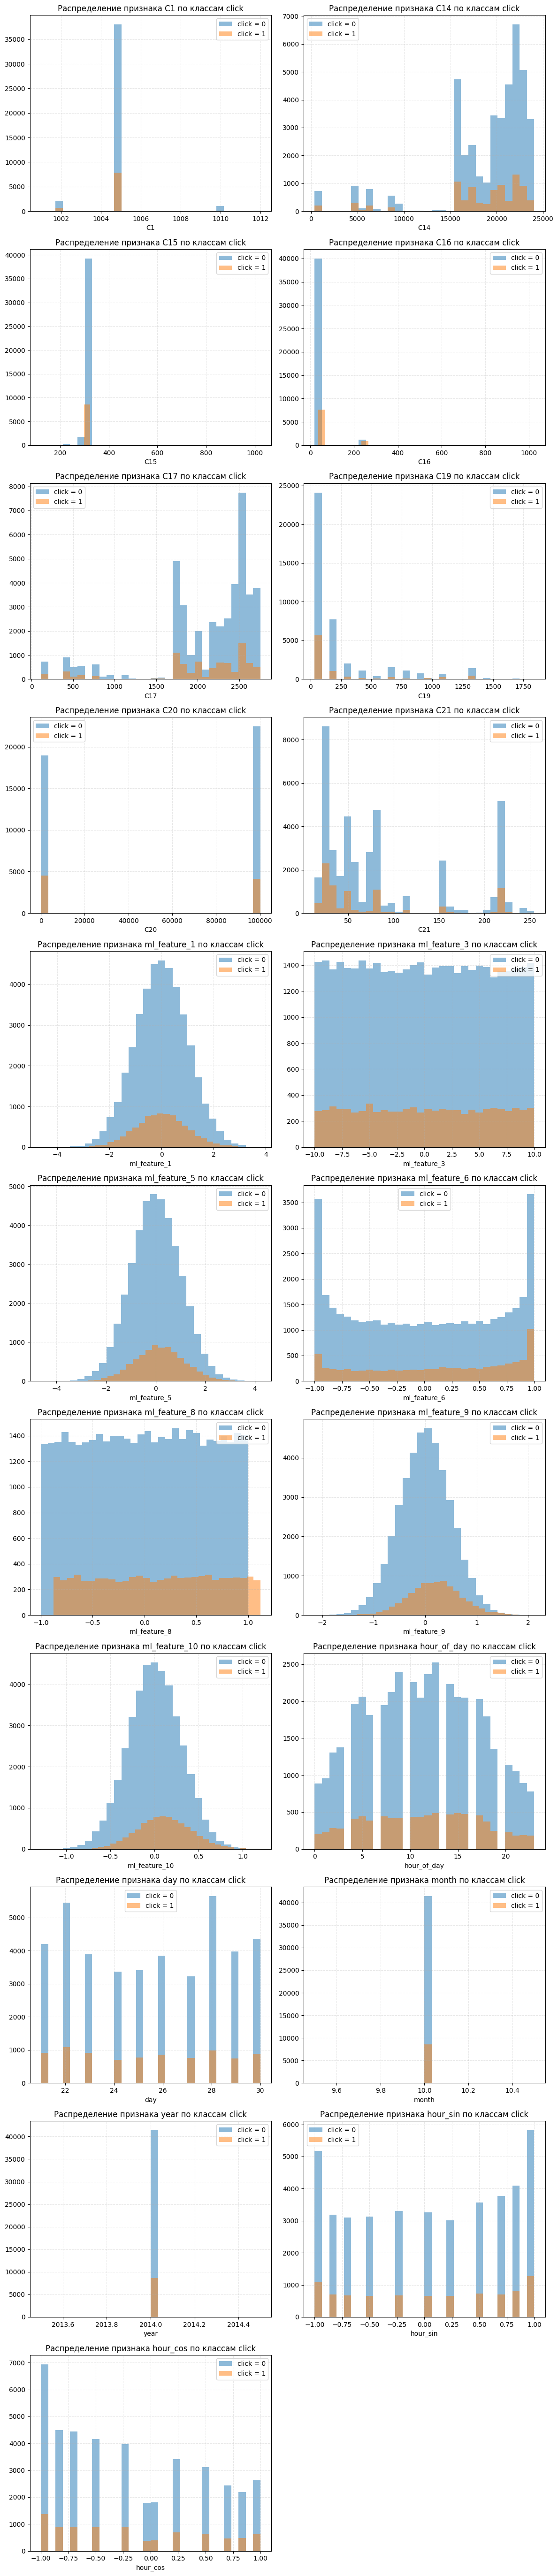

In [74]:
boxplot_describe(feature_names_list=num_cols[2:], df=df, density=False)

Анализ:
- распределение признаков ml_feature_1, ml_feature_5, ml_feature_9, ml_feature_10 можно приблизить нормальным, имеет смысл применить z-score фильтрацию и отсечь хвосты распределений 
- С15, С16, C19 - распредедение признаков сильно скошено. Рассмотрим преобразование логарифмом для более равномерного распределения по диапазону
- необходимо провести дополнительный анализ количественных признаков с дискретным набором значений

#### Количественные признаки с дискретным набором значений

In [75]:
num_nunique_mask = df[num_cols].nunique() < 100
num_cols_special = df[num_cols].nunique()[num_nunique_mask].index.to_list()

In [76]:
df[num_cols_special].describe()

,click,C1,C15,C16,C19,C21,hour_of_day,day,month,year,hour_sin,hour_cos
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.0,5.000000e+04,50000.000000
mean,0.172060,1004.970060,318.86640,59.692480,227.703800,83.685180,11.221500,25.478220,10.0,2014.0,4.729782e-02,-0.198552
std,0.377436,1.110202,20.56153,46.720842,351.592108,70.539513,5.938008,2.964945,0.0,0.0,7.194056e-01,0.663939
min,0.000000,1001.000000,120.00000,20.000000,33.000000,13.000000,0.000000,21.000000,10.0,2014.0,-1.000000e+00,-1.000000
25%,0.000000,1005.000000,320.00000,50.000000,35.000000,23.000000,6.000000,23.000000,10.0,2014.0,-7.071068e-01,-0.866025
50%,0.000000,1005.000000,320.00000,50.000000,39.000000,61.000000,11.000000,26.000000,10.0,2014.0,1.224647e-16,-0.258819
75%,0.000000,1005.000000,320.00000,50.000000,171.000000,108.000000,16.000000,28.000000,10.0,2014.0,7.071068e-01,0.500000
max,1.000000,1012.000000,1024.00000,1024.000000,1839.000000,255.000000,23.000000,30.000000,10.0,2014.0,1.000000e+00,1.000000


In [77]:
df['C20'].value_counts() / len(df['C20']) * 100

C20
-1         46.886
 100084     6.018
 100148     4.442
 100111     4.220
 100077     3.916
            ...  
 100213     0.004
 100121     0.004
 100024     0.002
 100229     0.002
 100178     0.002
Name: count, Length: 149, dtype: float64

Неявные пропуски:
- для признака C20 значения -1 скорее всего являются обозначением пропусков
- количество пропусков 46.9%, что довольно существенно. Заменим на статистику распределения - медиану (после разбиения на train/test)
- на данный момент необходимо сделать эти припуски явными и заменить на Nan

Выбросы:
-  С15, С16, C19, C21 имеют выбросы (максимальное значение существенно отличается от 75 перцентиля)
- можно рассмотреть замену этих значений на моду 

In [78]:
df['C20'] = df['C20'].replace(-1, np.nan) # теперь пропуски явные

Выявление константных признаков

In [79]:
def get_quasi_constant_features(
    df: pd.DataFrame,
    num_threshold: float = 0.0,
    cat_threshold: float = 1.0,
) -> list[str]:
    quasi_num_cols = []
    quasi_cat_cols = []

    # Числовые признаки
    numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    if numerical_columns:
        numerical_data = df[numerical_columns]

        vs_quasi = VarianceThreshold(threshold=num_threshold)
        vs_quasi.fit(numerical_data)
        quasi_num_cols = [
            col for col, keep in zip(numerical_columns, vs_quasi.get_support()) if not keep
        ]

    # Категориальные признаки
    categorical_columns = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    for col in categorical_columns:
        freqs = df[col].value_counts(normalize=True, dropna=False)
        if not freqs.empty and freqs.iloc[0] >= cat_threshold:
            quasi_cat_cols.append(col)

    quasi_constant_cols = quasi_num_cols + quasi_cat_cols
    return quasi_constant_cols


In [80]:
сonstant_features = get_quasi_constant_features(df=df, num_threshold=0, cat_threshold=1)
сonstant_features

['month', 'year']

- признаки month year константные, их стоит удалить сразу. Они бесполезны для модели

### 2.4 Фильтрация признаков

Фильтрация явно бесполезных признаков: идентификаторы пользователей, сайтов, устройств, домены сайтов, ip адреса и модели устройств пользователей:
- id, site_id, site_domain, device_id, device_ip, device_model

Убираем константные признаки, поскольку они бесполезны для модели

Остальные признаки потенциально полезны для анализа

In [81]:
df = df.drop(columns=['id', 'site_id', 'site_domain', 'device_id', 'device_ip', 'device_model'] + сonstant_features)
df.head()

,click,C1,banner_pos,site_category,app_id,app_domain,app_category,device_type,device_conn_type,C14,...,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10,hour_of_day,day,hour_sin,hour_cos
0,1,1005,1,f028772b,ecad2386,7801e8d9,07d7df22,1,0,17614,...,0.817292,0.993275,Z,-0.619959,0.433666,0.274038,0,21,0.0,1.0
1,0,1005,0,28905ebd,ecad2386,7801e8d9,07d7df22,1,0,15701,...,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851,0,21,0.0,1.0
2,0,1005,0,f028772b,ecad2386,7801e8d9,07d7df22,1,0,17914,...,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487,0,21,0.0,1.0
3,0,1005,0,50e219e0,39cfef32,d9b5648e,0f2161f8,1,0,21611,...,0.062795,0.062934,Y,0.551982,0.733382,-0.198542,0,21,0.0,1.0
4,0,1005,0,28905ebd,ecad2386,7801e8d9,07d7df22,1,0,15702,...,-0.675276,0.797144,X,0.640827,0.297955,-0.136909,0,21,0.0,1.0


#### Анализ квази-константных признаков

In [82]:
get_quasi_constant_features(df, num_threshold=0.1, cat_threshold=.95)

['ml_feature_10']

Анализ:

- Среди квази-константных можно выделить ml_feature_10 с дисперсией менее 0.1. Пока решение об удалении не принимаем. Распределение по значениям не выгдядит, как костантное. Помимо этого, признак имеет корреляцию с целевой переменной выше 0.1 (в теории может быть полезен)

### 2.5 Итог:

1. Базовая инфомация:
    - 50000 объектов
    - 33 признака и целевая переменная 
    - 11 категориальных и 22 числовых признака, целевая переменная в виде числа
    - данные не содержат явных пропусков

2. Целевая переменная:
    - среди классов наблюдается дисбаланс: 83% пропусков рекламы, 17% кликов
    - при разделениий на выброки необходимо применять стратификацию

3. Анализ признаков.

    a) Категориальные признаки:
    - признаки site_id, site_domain, app_id, device_id, device_ip, device_model содержат большое количество уникальных значений. Присутствует техническая информация, связанная с процессом сбора данных. Кандидаты на удаление.
    - категориальные признаки с большим количеством уникальных значений (>10) рекомендовано кодировать с помощью **TargetEncoder** (site_category, app_id, app_domain, app_category), чтобы не рездувать признаковое пространство. Остальные кодируем с помощью **OneHot** (ml_feature_2, ml_feature_7)
    - доля целевых классов внутри признаков ml_feature_7, ml_feature_2 практически не отличается. Кандидаты на удаление.
    - высокая корреляция (от 0.94 и до 1) между признаками: app_id, app_domain, app_category. Для избежания проблемы мультиколлинеарности стоит оставить только один из них. Можно оставить наиболее скоррелированный с целевой переменной
    - наиболее связан с click признак app_id: 0.221436
    - наименее связанные признаки с click (кандидаты на удаление): 
        - ml_feature_7:     0.022622
        - ml_feature_2:     0.003790
    
    b) Количественные признаки:

   - высокие коэффициенты корреляции:
    - C14, C17 -  0.99
    - C1, device_type - 0.92
    - C15, C16 - 0.88
    - hours_sin, hours_cos - 0.9

    - наиболее скоррелированные признаки с целевой переменной (их точно стоит оставить): 
        - 'C18', 'ml_feature_9', 'ml_feature_10', 'C21', 'ml_feature_8',
            'device_conn_type', 'C16', 'C14', 'C15'
    - наименее скорреированные с целевой переменной (кандидаты на удаление):
        - 'ml_feature_1', 'hour_sin', 'ml_feature_4', 'ml_feature_3', 'id'
    - Распределения с выбросами:
        - распределение признаков ml_feature_1, ml_feature_5, ml_feature_9, ml_feature_10 по виду близкое к нормальному, имеет смысл применить z-score фильтрацию и отсечь хвосты распределений 
        -  С15, С16  имеют выбросы. Стоит применить фильтрацию с заменой выбросов на моду
        - после разделения на train/test стоит провести z-score фильтрацию по 3 сигма для количественных данных, чтобы отсеять выбросы в распределениях

4. Преобразование признаков
- признак hour был преобразован из int формата YYMMDDHH в формат дат: year, month, day, hour_of_day
- для учета цикличности были добавлены признаки: hour_cos, hour_sin
- признак hour был удален

5. Фильтрация.

- По результатам анализа выявлены признаки, бесполезные для дальнейшего анализа. Среди них: идентификаторы пользователей, сайтов, устройств, домены сайтов, ip адреса и модели устройств пользователей.
- id, site_id, site_domain, device_id, device_ip, device_model
- Константные признаки: month, year также бесполезны для модели
- Указанные признаки были удалены.

6. Неявные пропуски:
- найдены неявные пропуски в C20: значения -1. Для последующей корректной обработки флаги были изменены на np.nan

7. Константные и квази-константные признаки
- сгенерированные признаки year, month оказались константными и были удалены за ненадобностью
- признак ml_feature_10 определен алгоритмом как квази константный с порогом 0.1 по стандартному отклонению. Но, исходя из корреляционного анализа, он выглядит перспективным. Поэтому его не рекомендуется удалять на данном этапе

8. Наиболее перспективные признаки для модели:
-  app_id
- C18                
- ml_feature_9        
- ml_feature_10      
- C21                 
- ml_feature_8        
- device_conn_type    
- C16                 
- C14                 

9. Что нужно сделать в предобработке (на train):
- отмасштабировать все признаки 
- z-score фильтрацию по 3 сигма для признаков, распределение которых может быть аппроксимировано нормальным, чтобы отсеять выбросы в распределениях
- заменить пропуски в C20 на медианные значение 
- применить логрифмирование к сильно скошенным распределениям для С15, С16, C19
- кодирование категориальных признаков: Target/OneHot
- провести еще раз корреляционный анализ и отсеять мало связанные с целевой переменной признаки (еще раз проверить кандидатов), отсеять сильно скоррелированные между собой признаки


## 3. Разделение данных на выборки

In [83]:
X = df.drop(columns=['click'])
y = df['click']

In [84]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)


X_calib, X_train, y_calib, y_train = train_test_split(
    X_train_full, y_train_full, test_size=0.8, random_state=RANDOM_SEED, stratify=y_train_full
)

In [85]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape, X_calib.shape, y_calib.shape

((32000, 30), (10000, 30), (32000,), (10000,), (8000, 30), (8000,))

In [86]:
# Доля целевых классов в обучающей выборке
for name, data in zip(['train', 'test', 'calib'], [y_train, y_test, y_calib]):
    print(f'Доля классов в {name} выборке:')
    print(data.value_counts() / len(data) * 100)
    print('-'*30)


Доля классов в train выборке:
click
0    82.79375
1    17.20625
Name: count, dtype: float64
------------------------------
Доля классов в test выборке:
click
0    82.79
1    17.21
Name: count, dtype: float64
------------------------------
Доля классов в calib выборке:
click
0    82.8
1    17.2
Name: count, dtype: float64
------------------------------


- разбиение на train/calib/test прошло ожидаемо, стратификация корректна 

## 4. Фильтрация признаков

In [87]:
# числовые признаки
num_cols_tot = X_train.select_dtypes(include=[np.number]).columns.tolist()
num_cols_tot

['C1',
 'C14',
 'C15',
 'C16',
 'C17',
 'C19',
 'C20',
 'C21',
 'ml_feature_1',
 'ml_feature_3',
 'ml_feature_5',
 'ml_feature_6',
 'ml_feature_8',
 'ml_feature_9',
 'ml_feature_10',
 'hour_of_day',
 'day',
 'hour_sin',
 'hour_cos']

In [88]:
# категориальные признаки
cat_cols = X_train.select_dtypes(include=cat_cols_types).columns.tolist()
cat_cols

['banner_pos',
 'site_category',
 'app_id',
 'app_domain',
 'app_category',
 'device_type',
 'device_conn_type',
 'C18',
 'ml_feature_2',
 'ml_feature_4',
 'ml_feature_7']

### 4.1 Фильтрация на основе корреляционного анализа признаков

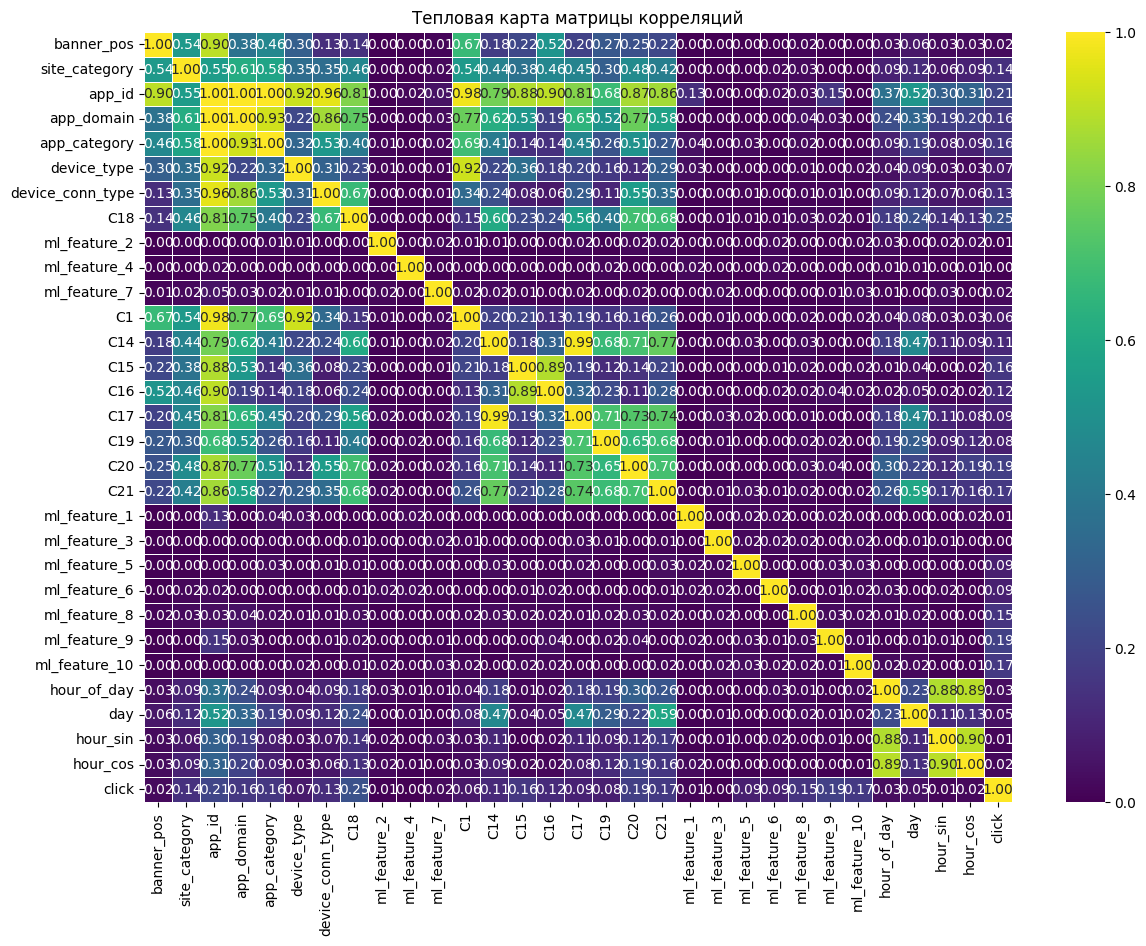

In [89]:
corr_with_target = get_target_corr(
    data=pd.concat([X_train, y_train], axis=1), 
    feat_cols=cat_cols + num_cols_tot + ['click'], 
    num_cols=num_cols_tot, 
    target_col_name='click'
    )

In [90]:
corr_with_target.head(15)

click               1.000000
C18                 0.251398
app_id              0.210240
ml_feature_9        0.193536
C20                 0.185807
ml_feature_10       0.167837
C21                 0.167125
C15                 0.163635
app_domain          0.160674
app_category        0.159276
ml_feature_8        0.149773
site_category       0.138173
device_conn_type    0.131811
C16                 0.117264
C14                 0.114317
Name: click, dtype: float64

In [91]:
# отбираем признаки с низкой корреляцией
threshold = 0.05
low_corr_features = corr_with_target[corr_with_target < threshold].index
low_corr_features

Index(['day', 'hour_of_day', 'ml_feature_7', 'banner_pos', 'hour_cos',
       'hour_sin', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3',
       'ml_feature_4'],
      dtype='object')

Чтобы уйти от мультиколлинеарности, необходимо удалять признаки с высокой взаимной корреляцией. Например, для всей выброки train это:
- app_domain, app_category, C1, device_conn_type - корреляция с app_id выше 0.95
- С17 коррелирует с C14: corr = 0.99. Убираем С17, поскольку менее скоррелирована с click
- корреляция между hour_sin, hour_cos, hours_of_day: >0.85.

Рекомендация:
- встраиваем в пайплайн обработку высоко скоррелированных признаков. Среди пар высоко скоррелированных будем убирать те, которые меньше коррелируют с целевой переменной

### 4.2 Фильтрация по вариации `VarianceThreshold`.

In [92]:
X_train.head()

,C1,banner_pos,site_category,app_id,app_domain,app_category,device_type,device_conn_type,C14,C15,...,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10,hour_of_day,day,hour_sin,hour_cos
8741,1005,0,50e219e0,4b08f369,2347f47a,0f2161f8,1,2,21767,320,...,-0.331355,0.107023,Z,-0.606576,0.970097,0.532949,12,22,1.224647e-16,-1.000000
37586,1005,0,50e219e0,ce183bbd,ae637522,cef3e649,1,0,23441,320,...,0.515121,0.549117,X,0.397841,0.956077,0.305653,14,28,-5.000000e-01,-0.866025
36557,1005,1,f028772b,ecad2386,7801e8d9,07d7df22,1,0,8330,320,...,-0.392676,-0.547673,Y,0.645691,0.236324,0.582635,12,28,1.224647e-16,-1.000000
1116,1005,0,f028772b,ecad2386,7801e8d9,07d7df22,1,0,8330,320,...,0.015672,-0.438968,Z,-0.919800,-0.329426,0.226170,4,21,8.660254e-01,0.500000
37368,1005,4,f028772b,ecad2386,7801e8d9,07d7df22,1,0,15908,320,...,0.650988,0.044702,Y,-0.646847,-0.118124,-0.127781,14,28,-5.000000e-01,-0.866025


In [93]:
сols_to_drop_var = get_quasi_constant_features(df=X_train, num_threshold=0.05, cat_threshold=0.95)
сols_to_drop_var


[]

- квази константых признаков нет

Итог:
- реализована функция фильтрации признаков: фильтрация признаков малосвязанных с целевой переменной, фильтрация сильно скоррелированных между собой признаков, фильтрация квазиконстантных признаков
- в дальнейшем фильтрация будет встроена в общий пайплайн

## 5. Предобработка данных — построение пайплайнов

In [94]:
class ZScoreOutlierReplacer(BaseEstimator, TransformerMixin):
    """Класс фильтрации z-score"""
    def __init__(self, z_threshold: float = 3.0):
        self.z_threshold = z_threshold

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.means_ = np.nanmean(X, axis=0)
        self.stds_ = np.nanstd(X, axis=0)
        self.medians_ = np.nanmedian(X, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()

        safe_stds = np.where(self.stds_ == 0, 1, self.stds_)
        z = np.abs((X - self.means_) / safe_stds)

        outlier_mask = z > self.z_threshold
        X[outlier_mask] = np.take(self.medians_, np.where(outlier_mask)[1])
        return X

    def set_output(self, *, transform=None):
        self._transform_output = transform
        return self
    
    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


def replace_zscore_outliers_with_median(z_threshold: float = 3.0):
    return ZScoreOutlierReplacer(z_threshold=z_threshold)


In [95]:
class CustomPreprocessor(BaseEstimator, TransformerMixin):
    """
    Обёртка над ColumnTransformer, которая:
    - обучает внутренний preprocessor
    - преобразует данные
    - возвращает pd.DataFrame с именами признаков
    """

    def __init__(self, preprocessor):
        self.preprocessor = preprocessor

    def fit(self, X, y=None):
        self.preprocessor_ = clone(self.preprocessor)
        self.preprocessor_.fit(X, y)
        self.feature_names_ = self.preprocessor_.get_feature_names_out()
        return self

    def transform(self, X):
        X_transformed = self.preprocessor_.transform(X)

        if sparse.issparse(X_transformed):
            X_transformed = X_transformed.toarray()

        return pd.DataFrame(
            X_transformed,
            columns=self.feature_names_,
            index=X.index
        )

    def fit_transform(self, X, y=None):
        self.preprocessor_ = clone(self.preprocessor)
        X_transformed = self.preprocessor_.fit_transform(X, y)
        self.feature_names_ = self.preprocessor_.get_feature_names_out()

        if sparse.issparse(X_transformed):
            X_transformed = X_transformed.toarray()

        return pd.DataFrame(
            X_transformed,
            columns=self.feature_names_,
            index=X.index
        )

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_, dtype=object)


In [96]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Фильтрация признаков по корреляции:
    1. удаляет признаки с низкой корреляцией с целевой переменной;
    2. из пар сильно скоррелированных признаков оставляет тот,
       который сильнее связан с целевой переменной.
    """

    def __init__(self, low_target_threshold=0.05, high_corr_threshold=0.90):
        self.low_target_threshold = low_target_threshold
        self.high_corr_threshold = high_corr_threshold

    def _to_dataframe(self, X, columns=None, index=None):
        
        if isinstance(X, pd.DataFrame):
            return X.copy()

        if columns is None:
            columns = [f'x{i}' for i in range(X.shape[1])]

        return pd.DataFrame(X, columns=columns, index=index)

    def fit(self, X, y):
        """Отбор признаков по корреляции между собой и с целевой переменной."""

        X_df = self._to_dataframe(X)
        self.feature_names_in_ = np.asarray(X_df.columns, dtype=object)

        y_series = pd.Series(y, index=X_df.index, name='target')
        target_corr = X_df.corrwith(y_series).abs().fillna(0.0)
        self.target_corr_ = target_corr

        self.low_corr_features_ = target_corr[
            target_corr < self.low_target_threshold
        ].index.tolist()

        X_filtered = X_df.drop(columns=self.low_corr_features_, errors='ignore')
        self.high_corr_features_ = []

        if X_filtered.shape[1] > 1:
            feature_corr = X_filtered.corr().abs().fillna(0.0)
            upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)

            high_corr_pairs = (
                feature_corr.where(upper_mask)
                .stack()
                .reset_index()
                .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr'})
                .query('corr > @self.high_corr_threshold')
                .sort_values('corr', ascending=False)
                .reset_index(drop=True)
            )

            dropped = set()
            for _, row in high_corr_pairs.iterrows():
                feature_1 = row['feature_1']
                feature_2 = row['feature_2']

                if feature_1 in dropped or feature_2 in dropped:
                    continue

                corr_1 = target_corr.get(feature_1, 0.0)
                corr_2 = target_corr.get(feature_2, 0.0)

                if corr_1 < corr_2:
                    dropped.add(feature_1)
                else:
                    dropped.add(feature_2)

            self.high_corr_features_ = [col for col in X_filtered.columns if col in dropped]

        cols_to_drop = set(self.low_corr_features_) | set(self.high_corr_features_)
        self.cols_to_drop_ = [col for col in self.feature_names_in_ if col in cols_to_drop]
        return self

    def transform(self, X):
        X_df = self._to_dataframe(X, columns=self.feature_names_in_)
        return X_df.drop(columns=self.cols_to_drop_, errors='ignore')

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.asarray([col for col in input_features if col not in self.cols_to_drop_], dtype=object)


In [97]:
COLS_NORM_DIST = ['ml_feature_1', 'ml_feature_5', 'ml_feature_9', 'ml_feature_10']
SPECIAL_WITH_OUTLIERS = ['C15', 'C16', 'C19']

def select_cat_one_hot(X):
    cat_cols = X.select_dtypes(include=cat_cols_types).columns.tolist()
    return [name for name in cat_cols if X[name].nunique() < 10]

def select_cat_target(X):
    cat_cols = X.select_dtypes(include=cat_cols_types).columns.tolist()
    return [name for name in cat_cols if X[name].nunique() >= 10]

def select_num_continues_norm_dist(X):
    num_cols_continues = X.select_dtypes(include=['float']).columns.tolist()
    return [name for name in num_cols_continues if name in COLS_NORM_DIST]

def select_num_continues_other_dist(X):
    num_cols_continues = X.select_dtypes(include=['float']).columns.tolist()
    return [name for name in num_cols_continues if name not in COLS_NORM_DIST]

def select_num_special(X):
    num_cols_special = X.select_dtypes(include=['int']).columns.tolist()
    return [name for name in num_cols_special if name not in SPECIAL_WITH_OUTLIERS]

def select_num_special_outliers(X):
    num_cols_special = X.select_dtypes(include=['int']).columns.tolist()
    return [name for name in num_cols_special if name in SPECIAL_WITH_OUTLIERS]

In [98]:
def create_preprocessing_pipeline(
    with_filtering: bool = True,
    low_target_threshold=0.05,
    high_corr_threshold=0.90
) -> Pipeline:
    """
    Создание пайплайна предобратботки данных.

    Args:
        with_filtering (bool): Включать ли фильтрацию признаков.
    Returns:
        Pipeline: Пайплайн фильтрации и предобработки данных
    """

    # Пайплайны для разных типов признаков
    cat_one_hot_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])

    cat_target_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder())
    ])

    num_cols_continues_norm_dist_pipeline = Pipeline(steps=[
        ('outliers', replace_zscore_outliers_with_median(z_threshold=3.0)),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])  

    num_cols_continues_other_dist_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())
    ])

    num_special_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', MinMaxScaler())
    ])
    num_special_special_outliers_pipeline = Pipeline(steps=[
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('scaler', RobustScaler()),
    ])
    transformers = [
        ('cat_one_hot', cat_one_hot_pipeline, select_cat_one_hot),
        ('cat_target', cat_target_pipeline, select_cat_target),
        ('num_continues_norm_dist', num_cols_continues_norm_dist_pipeline, select_num_continues_norm_dist),
        ('num_continues_other_dist', num_cols_continues_other_dist_pipeline, select_num_continues_other_dist),
        ('special', num_special_pipeline, select_num_special),
        ('special_outliers', num_special_special_outliers_pipeline, select_num_special_outliers),
    ]
    
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop'
    )

    result_pipeline = [
        ('prep', CustomPreprocessor(preprocessor))
    ]
    if with_filtering:
        result_pipeline.append(
            ('corr_filter', CorrelationFilter(  # фильтрация по корреляции
                low_target_threshold=low_target_threshold,
                high_corr_threshold=high_corr_threshold
            ))
        )

    return Pipeline(result_pipeline)


## 6. Базовые модели

### Настройки кросс-валидации

In [99]:
N_FOLDS = 5

# Настройка кросс-валидации
# классы несбалансированы, применяем стратификацию
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)  

#### Базовый пайплайн обработки

In [100]:
preprocessor_base = create_preprocessing_pipeline(with_filtering=False)

### 6.1 `DummyClassifier`


In [101]:
dummy_model = DummyClassifier()

In [102]:
pipeline_dummy = Pipeline([
    ('prep', preprocessor_base),
    ('model', dummy_model)
])

In [103]:
pipeline_dummy.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('prep',
                                  CustomPreprocessor(preprocessor=ColumnTransformer(transformers=[('cat_one_hot',
                                                                                                   Pipeline(steps=[('imputer',
                                                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                                                   ('encoder',
                                                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                                                  sparse_output=False))]),
                                                                                                   <function select_cat_one_hot at 0x177aa3c10>),
                                                                                                  ('cat_target',
                                                                                                   Pipeline(steps=[('imputer...
                                                                                                   Pipeline(steps=[('imputer',
                                                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                                                   ('scaler',
                                                                                                                    MinMaxScaler())]),
                                                                                                   <function select_num_special at 0x1776e7a60>),
                                                                                                  ('special_outliers',
                                                                                                   Pipeline(steps=[('log',
                                                                                                                    FunctionTransformer(feature_names_out='one-to-one',
                                                                                                                                        func=<ufunc 'log1p'>)),
                                                                                                                   ('scaler',
                                                                                                                    RobustScaler())]),
                                                                                                   <function select_num_special_outliers at 0x1776e7af0>)])))])),
                ('model', DummyClassifier())])

In [104]:
y_proba_dummy = cross_val_predict(
    pipeline_dummy, X_train, y_train, cv=kfold, method='predict_proba'
    )[:, 1]

### 6.2 `LogisticRegression`

In [105]:
logreg_basic = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)

In [106]:
pipeline_logreg_basic = Pipeline([
    ('prep', preprocessor_base),
    ('model', logreg_basic)
])

In [107]:
y_proba_logreg_basic = cross_val_predict(
    pipeline_logreg_basic, X_train, y_train, cv=kfold, method='predict_proba'
    )[:, 1]

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: 

### 6.3 `SVC`

In [108]:
svc_basic = SVC(
    kernel='linear',
    probability=False,
    random_state=RANDOM_SEED
)

In [109]:
pipeline_svc_basic = Pipeline([
    ('prep', preprocessor_base),
    ('model', svc_basic)
])

In [110]:
y_proba_svc_basic = cross_val_predict(
    pipeline_svc_basic,
    X_train,
    y_train,
    cv=kfold,
    method='decision_function',
    verbose=1,
    n_jobs=-1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   13.6s finished


### 6.4 Сравнение базовых моделей

In [111]:
def plot_pr_auc_curve(y_true, y_probas, labels, title='Precision-Recall Curve'):

    plt.figure(figsize=(14, 10))

    result = dict()
    for y_proba, label in zip(y_probas, labels):
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        plt.plot(recall, precision, lw=2, label=f'{label}. AP = {ap:.3f}')
        print(f'{label} AP:', ap)
        result[label] = ap

    baseline = y_true.mean()
    plt.axhline(
        y=baseline,
        color='k',
        linestyle='--',
        linewidth=1,
        label=f'Baseline = {baseline:.3f}'
    )

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.show()

    return result


Dummy модель AP: 0.17203750454050126
Базовая LogReg модель AP: 0.3823176277597546
Базовая SVC модель AP: 0.24993694621906926


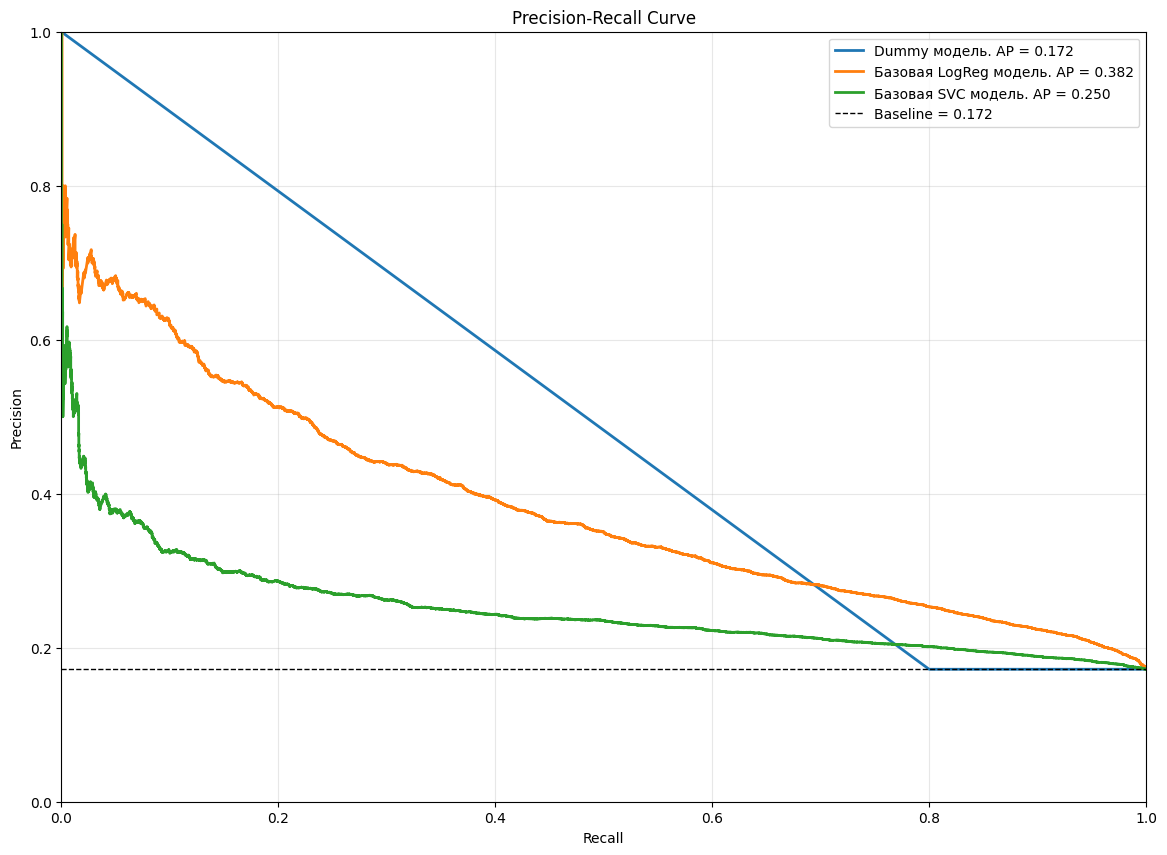

In [112]:
pr_auc_base = plot_pr_auc_curve(
    y_train, 
    [y_proba_dummy, y_proba_logreg_basic, y_proba_svc_basic], 
    labels=['Dummy модель', 'Базовая LogReg модель', 'Базовая SVC модель']
)

In [113]:
pr_auc_base

{'Dummy модель': np.float64(0.17203750454050126),
 'Базовая LogReg модель': np.float64(0.3823176277597546),
 'Базовая SVC модель': np.float64(0.24993694621906926)}

Анализ:
- модели LogReg и SVC обучаются корректно, они лучше baseline по метрике average precision
- LogReg ap существенно превосходит SVC ap 

### Оценка влияния фильтрации на качество базовых моделей

In [114]:
# обновленный пайплайн предобработки 
preprocessor_filtered = create_preprocessing_pipeline(with_filtering=True)

In [115]:
pipeline_dummy_filtered = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', dummy_model)
])
pipeline_logreg_filtered = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', logreg_basic)
])
pipeline_svc_filtered = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', svc_basic)
])

Аналогично обучаем модели и сравниваем результаты

In [116]:
y_proba_dummy_filtered = cross_val_predict(
    pipeline_dummy_filtered, X_train, y_train, cv=kfold, method='predict_proba', verbose=1
    )[:, 1]

y_proba_logreg_basic_filtered = cross_val_predict(
    pipeline_logreg_filtered, X_train, y_train, cv=kfold, method='predict_proba', verbose=1, n_jobs=-1
)[:, 1]

y_proba_svc_basic_filtered = cross_val_predict(
    pipeline_svc_filtered, X_train, y_train, cv=kfold, method='decision_function', verbose=1, n_jobs=-1
)


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise 

Dummy модель AP: 0.17203750454050126
Базовая LogReg модель AP: 0.3811672649507748
Базовая SVC модель AP: 0.2962377591025196


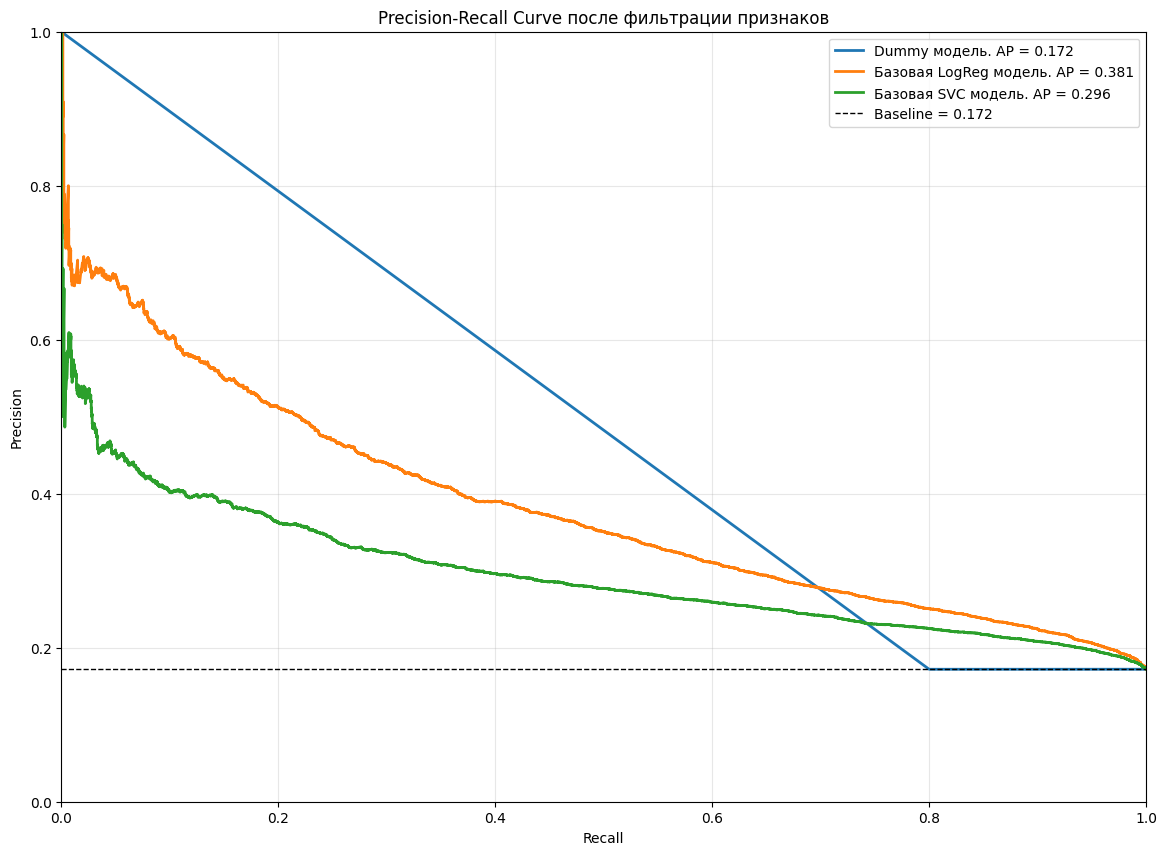

In [117]:
pr_auc_filtered = plot_pr_auc_curve(
    y_train, 
    [y_proba_dummy_filtered, y_proba_logreg_basic_filtered, y_proba_svc_basic_filtered], 
    labels=['Dummy модель', 'Базовая LogReg модель', 'Базовая SVC модель'],
    title='Precision-Recall Curve после фильтрации признаков'
)


In [118]:
pr_auc_filtered

{'Dummy модель': np.float64(0.17203750454050126),
 'Базовая LogReg модель': np.float64(0.3811672649507748),
 'Базовая SVC модель': np.float64(0.2962377591025196)}

In [119]:
pr_auc_base

{'Dummy модель': np.float64(0.17203750454050126),
 'Базовая LogReg модель': np.float64(0.3823176277597546),
 'Базовая SVC модель': np.float64(0.24993694621906926)}

In [120]:
# изменение метрики после фильтрации признаков
for model in pr_auc_base.keys():
    change = (pr_auc_filtered[model] - pr_auc_base[model]) / pr_auc_base[model] * 100
    print(f'{model}: изменение AP = {change:.4f} %')

Dummy модель: изменение AP = 0.0000 %
Базовая LogReg модель: изменение AP = -0.3009 %
Базовая SVC модель: изменение AP = 18.5250 %


Анализ:
- после фильтрации мало значимых признаков ключевая метрика для LogReg модели несущественно ухудшилась
- для SVC модели фильтрация существенно улучшилась

Итог:
- фильтрацию имеет смысл оставить. Это повысит скорость работы и стабильность моделей

## 7 Отбор признаков с помощью методов-оберток
- используем метод отбора RFE (Recursive Feature Elimination)

In [121]:
svm_base_model = SVC(
    random_state=RANDOM_SEED,
    kernel='linear',
    probability=False
)
preprocessor = create_preprocessing_pipeline(with_filtering=False)

In [122]:
def select_features_rfe(
    X,
    y,
    rfe_base_estimator,
    preprocessor,
    n_features_to_select=10,
    step=1,
):
    """Отбор признаков с помощью RFE."""
    pipeline = Pipeline([
        ('prep', clone(preprocessor)),
        ('selector', RFE(
            estimator=clone(rfe_base_estimator),
            n_features_to_select=n_features_to_select,
            step=step,
        )),
    ])

    pipeline.fit(X, y)

    prep = pipeline.named_steps['prep']
    selector = pipeline.named_steps['selector']

    feature_names = prep.get_feature_names_out()
    selected_features = feature_names[selector.support_].tolist()

    feature_ranking = (
        pd.Series(selector.ranking_, index=feature_names, name='ranking')
        .sort_values()
    )

    return {
        'pipeline': pipeline,
        'selected_features': selected_features,
        'feature_ranking': feature_ranking,
    }


In [123]:
selected_rfe_feat = select_features_rfe(X=X_train, y=y_train, rfe_base_estimator=svm_base_model, preprocessor=preprocessor)
selected_rfe_feat

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

{'pipeline': Pipeline(steps=[('prep',
                  Pipeline(steps=[('prep',
                                   CustomPreprocessor(preprocessor=ColumnTransformer(transformers=[('cat_one_hot',
                                                                                                    Pipeline(steps=[('imputer',
                                                                                                                     SimpleImputer(strategy='most_frequent')),
                                                                                                                    ('encoder',
                                                                                                                     OneHotEncoder(handle_unknown='ignore',
                                                                                                                                   sparse_output=False))]),
                                                                             

In [124]:
base_features = sorted(set(
    feat.split('__', 1)[1].rsplit('_', 1)[0]
    if feat.startswith('cat_one_hot__')
    else feat.split('__', 1)[1]
    for feat in selected_rfe_feat['selected_features']
))
base_features

['C15',
 'C18',
 'app_category',
 'device_conn_type',
 'device_type',
 'ml_feature_8',
 'site_category']

In [125]:
base_num = [col for col in base_features if col in num_cols]
base_cat = [col for col in base_features if col in cat_cols]
corr_with_target_rfe = get_target_corr(pd.concat([X_train, y_train], axis=1), base_features + ['click'], num_cols=base_num, target_col_name='click', plot_corr_matrix=False)
print('Признаки, отобранные RFE: ')
corr_with_target_cat

Признаки, отобранные RFE: 


click               1.000000
C18                 0.257840
app_id              0.221436
app_domain          0.161289
app_category        0.156537
site_category       0.155008
device_conn_type    0.129954
device_type         0.071790
ml_feature_7        0.022622
banner_pos          0.022605
ml_feature_2        0.003790
ml_feature_4        0.000000
Name: click, dtype: float64

In [126]:
# Общий топ по корреляции с click
cols = X_train.columns.tolist() + [y_train.name]
corr_with_target_total = get_target_corr(
    pd.concat([X_train, y_train], axis=1), 
    feat_cols=cols, 
    num_cols=num_cols, 
    target_col_name='click', 
    plot_corr_matrix=False
)
corr_with_target_total.head(15)

click               1.000000
C18                 0.251398
app_id              0.210240
ml_feature_9        0.193536
C20                 0.185807
ml_feature_10       0.167837
C21                 0.167125
C15                 0.163635
app_domain          0.160674
app_category        0.159276
ml_feature_8        0.149773
site_category       0.138173
device_conn_type    0.131811
C16                 0.117264
C14                 0.114317
Name: click, dtype: float64

Анализ:
- среди отобранных с помощью алгоритма RFE в основном признаки высоко коррелированые c целевой переменной click
- важные для модели признаки содержат информацию о:
    - баннере/аукционе/пользователе - C18
    - рекламируемом приложении - app_* 
    - характеристиках сайта и расположения баннера - cite_category, banner_pos 
    - характеристиках устройства пользователя - device_*


## 8. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 8.1 Сетка гиперпараметров

In [127]:
# параметры кросс-валидации 
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

**LogisticRegression**

Варьируем параметры:
- C - коэффициент регуляризации
- penalty - Тип регуляризации
- class_weight - учет дисбаланса классов
- max_iter - сходимость
- solver - солвер

In [128]:
logreg_basic_param_grid = [
    {
        'model__solver': ['lbfgs'],
        'model__penalty': ['l2'],
        'model__C': np.logspace(-3, 2, 6),
        'model__class_weight': [None, 'balanced'],
        'model__max_iter': [1000],
    },
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': np.logspace(-3, 2, 6),
        'model__class_weight': [None, 'balanced'],
        'model__max_iter': [1000],
    },
    {
        'model__solver': ['saga'],
        'model__penalty': ['l1', 'l2'],
        'model__C': np.logspace(-3, 2, 6),
        'model__class_weight': [None, 'balanced'],
        'model__max_iter': [1000],
    },
]

**SVC**

In [129]:
svc_basic_param_grid = [
    {
        'model__kernel': ['linear'],
        'model__C': [0.1, 1, 10],
        'model__class_weight': ['balanced']
    },
    {
        'model__kernel': ['rbf'],
        'model__C': [1],
        'model__gamma': ['scale'],
        'model__class_weight': ['balanced']
    },
    {
        'model__kernel': ['poly'],
        'model__C': [1],
        'model__degree': [2],
        'model__gamma': ['scale'],
        'model__coef0': [0],
        'model__class_weight': ['balanced']
    }
]

#### 8.2 Применение Grid Search

In [130]:
def run_model_grid_search(
    model_name: str,
    pipeline: Pipeline,
    param_grid: list[dict],
    X: pd.DataFrame,
    y: pd.Series,
    cv,
    scoring: str = 'average_precision',
    n_jobs: int = -1,
    verbose=0,
):
    """Поиск лучших гиперпараметров с помощью GridSearchCV"""
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        refit=True,
        return_train_score=True,
        verbose=verbose,
    )

    grid_search.fit(X, y)

    best_score = grid_search.best_score_
    best_params = grid_search.best_params_
    results_df = pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score')

    print(f'Модель: {model_name}')
    print(f'Лучшая метрика ({scoring}): {best_score:.4f}')
    print('Лучшие параметры:')
    for param_name, param_value in best_params.items():
        print(f'  {param_name}: {param_value}')

    return {
        'model_name': model_name,
        'search': grid_search,
        'best_score': best_score,
        'best_params': best_params,
        'results_df': results_df,
    }

In [131]:
logreg_basic = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
preprocessor_filtered = create_preprocessing_pipeline(with_filtering=True)

pipeline_logreg_basic = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', logreg_basic)
])

logreg_grid_result = run_model_grid_search(
    model_name='LogisticRegression',
    pipeline=pipeline_logreg_basic,
    param_grid=logreg_basic_param_grid,
    X=X_train,
    y=y_train,
    cv=cv,
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: 

Модель: LogisticRegression
Лучшая метрика (average_precision): 0.3793
Лучшие параметры:
  model__C: 1.0
  model__class_weight: None
  model__max_iter: 1000
  model__penalty: l2
  model__solver: saga


In [132]:
logreg_grid_result['best_params'], logreg_grid_result['best_score']

({'model__C': np.float64(1.0),
  'model__class_weight': None,
  'model__max_iter': 1000,
  'model__penalty': 'l2',
  'model__solver': 'saga'},
 np.float64(0.3793007948515301))

In [133]:
svc_base = SVC(
    kernel='linear',
    random_state=RANDOM_SEED,
    probability=False
)
preprocessor_filtered = create_preprocessing_pipeline(with_filtering=True)

pipeline_svc_best = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', svc_base)
])


In [134]:
svc_grid_result = run_model_grid_search(
    model_name='SVC',
    pipeline=pipeline_svc_best,
    param_grid=svc_basic_param_grid,
    X=X_train,
    y=y_train,
    cv=cv,
)


/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Модель: SVC
Лучшая метрика (average_precision): 0.3773
Лучшие параметры:
  model__C: 0.1
  model__class_weight: balanced
  model__kernel: linear


In [135]:
svc_grid_result['best_params'], svc_grid_result['best_score']

({'model__C': 0.1,
  'model__class_weight': 'balanced',
  'model__kernel': 'linear'},
 np.float64(0.37731398590255266))

#### 8.3 Таблица результатов
- топ-10 конфигураций с их метриками.

In [136]:
def get_top_combined_grid_results(grid_results: list[dict], top_n: int = 10) -> pd.DataFrame:
    """Составление топа результатов"""
    combined_results = []

    for grid_result in grid_results:
        model_name = grid_result['model_name']
        results_df = grid_result['results_df'].copy()

        results_df['model_name'] = model_name

        results_df = results_df[
            [
                'model_name',
                'rank_test_score',
                'mean_test_score',
                'std_test_score',
                'mean_train_score',
                'std_train_score',
                'params'
            ]
        ]

        combined_results.append(results_df)

    final_df = pd.concat(combined_results, ignore_index=True)

    final_df = final_df.rename(
        columns={
            'rank_test_score': 'rank_within_model',
            'mean_test_score': 'mean_ap_test',
            'std_test_score': 'std_ap_test',
            'mean_train_score': 'mean_ap_train',
            'std_train_score': 'std_ap_train',
        }
    )

    final_df = final_df.sort_values(
        by=['mean_ap_test', 'std_ap_test'],
        ascending=[False, True]
    ).head(top_n).reset_index(drop=True)

    return final_df



In [137]:
top_logreg_models = get_top_combined_grid_results(
    grid_results=[logreg_grid_result], 
    top_n=5
)
top_logreg_models

,model_name,rank_within_model,mean_ap_test,std_ap_test,mean_ap_train,std_ap_train,params
0,LogisticRegression,1,0.379301,0.008022,0.407065,0.003515,"{'model__C': 1.0, 'model__class_weight': None,..."
1,LogisticRegression,2,0.379252,0.008022,0.408525,0.004751,"{'model__C': 10.0, 'model__class_weight': None..."
2,LogisticRegression,3,0.379150,0.008007,0.409578,0.003383,"{'model__C': 10.0, 'model__class_weight': None..."
3,LogisticRegression,4,0.379142,0.008539,0.406075,0.003591,"{'model__C': 0.1, 'model__class_weight': 'bala..."
4,LogisticRegression,5,0.379122,0.007699,0.407698,0.003661,"{'model__C': 10.0, 'model__class_weight': None..."


In [138]:
top_svc_models = get_top_combined_grid_results(
    grid_results=[svc_grid_result], 
    top_n=5
)
top_svc_models.iloc[0, :]['params']

{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}

## 9. Финальная модель

#### 9.1 Обучение финальной модели

Обучение лучших моделей: LogReg и SVC

In [139]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)  

In [140]:
def get_best_svc(
    top_svc_models: pd.DataFrame, 
    probability: bool = False, 
    random_state: int = RANDOM_SEED) -> SVC:
    best_svc_params = top_svc_models.iloc[0, :]['params']
    return SVC(
        **{k.replace('model__', ''): v for k, v in best_svc_params.items()},
        probability=probability,
        random_state=random_state
    )

In [141]:
svc_best = get_best_svc(top_svc_models, probability=True)
svc_best

SVC(C=0.1, class_weight='balanced', kernel='linear', probability=True,
    random_state=42)

In [142]:
preprocessor_filtered = create_preprocessing_pipeline(with_filtering=True)

pipeline_svc_best = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', svc_best)
])

In [143]:
# обучение
pipeline_svc_best.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('prep',
                                  CustomPreprocessor(preprocessor=ColumnTransformer(transformers=[('cat_one_hot',
                                                                                                   Pipeline(steps=[('imputer',
                                                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                                                   ('encoder',
                                                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                                                  sparse_output=False))]),
                                                                                                   <function select_cat_one_hot at 0x177aa3c10>),
                                                                                                  ('cat_target',
                                                                                                   Pipeline(steps=[('imputer...
                                                                                                   <function select_num_special at 0x1776e7a60>),
                                                                                                  ('special_outliers',
                                                                                                   Pipeline(steps=[('log',
                                                                                                                    FunctionTransformer(feature_names_out='one-to-one',
                                                                                                                                        func=<ufunc 'log1p'>)),
                                                                                                                   ('scaler',
                                                                                                                    RobustScaler())]),
                                                                                                   <function select_num_special_outliers at 0x1776e7af0>)]))),
                                 ('corr_filter', CorrelationFilter())])),
                ('model',
                 SVC(C=0.1, class_weight='balanced', kernel='linear',
                     probability=True, random_state=42))])

обучение лучшей модели логистической регрессии

In [144]:
def get_best_logreg(
    top_logreg_models: pd.DataFrame, 
    random_state: int = RANDOM_SEED
) -> LogisticRegression:
    best_logreg_params = top_logreg_models.iloc[0, :]['params']
    return LogisticRegression(
        **{k.replace('model__', ''): v for k, v in best_logreg_params.items()},
        random_state=random_state
    )

In [145]:
logreg_best = get_best_logreg(top_logreg_models)

In [146]:
preprocessor_filtered = create_preprocessing_pipeline(with_filtering=True)

pipeline_logreg_best = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', logreg_best)
])


In [147]:
# обучение
pipeline_logreg_best.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('prep',
                                  CustomPreprocessor(preprocessor=ColumnTransformer(transformers=[('cat_one_hot',
                                                                                                   Pipeline(steps=[('imputer',
                                                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                                                   ('encoder',
                                                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                                                  sparse_output=False))]),
                                                                                                   <function select_cat_one_hot at 0x177aa3c10>),
                                                                                                  ('cat_target',
                                                                                                   Pipeline(steps=[('imputer...
                                                                                                   <function select_num_special at 0x1776e7a60>),
                                                                                                  ('special_outliers',
                                                                                                   Pipeline(steps=[('log',
                                                                                                                    FunctionTransformer(feature_names_out='one-to-one',
                                                                                                                                        func=<ufunc 'log1p'>)),
                                                                                                                   ('scaler',
                                                                                                                    RobustScaler())]),
                                                                                                   <function select_num_special_outliers at 0x1776e7af0>)]))),
                                 ('corr_filter', CorrelationFilter())])),
                ('model',
                 LogisticRegression(C=np.float64(1.0), max_iter=1000,
                                    random_state=42, solver='saga'))])

#### 9.2 Расчет метрик на тестовой выборке



In [148]:
def learn_final_pipeline_with_metrics(final_pipeline, X_train, y_train, X_test, y_test):
    """Обучение финального пайплайна и расчет метрик на тестовой выборке"""
    
    scoring = ['average_precision', 'neg_brier_score'] 

    # Настройка кросс-валидации
    N_FOLDS = 5
    # классы несбалансированы, применяем стратификацию
    kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)  
    
    # кросс-валидация для улучшенной модели на отобранном наборе признаков
    cv_results = cross_validate(
        final_pipeline,
        X_train,
        y_train,
        scoring=scoring,
        cv=kfold
    )

    enhanced_means = {
        "pr_auc": cv_results["test_average_precision"].mean(),
        "brier": -cv_results["test_neg_brier_score"].mean()
    }

    # Обучение финального пайплайна 
    final_pipeline.fit(X_train, y_train)
    
    # Предсказания на тесте
    y_test_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]
    y_test_pred = final_pipeline.predict(X_test)
    # финальная метрика
    final_pr_auc = average_precision_score(y_test, y_test_pred_proba)
    final_brier = brier_score_loss(y_test, y_test_pred_proba)

    result = pd.DataFrame({
        'metric': ['PR-AUC', 'Brier score'],
        'cv_mean': [enhanced_means['pr_auc'], enhanced_means['brier']],
        'test_score': [final_pr_auc, final_brier],
        'difference, %': [
            round((final_pr_auc - enhanced_means['pr_auc']) / final_pr_auc * 100, 2),
            round((final_brier - enhanced_means['brier']) / final_brier * 100, 2)]
    })
    return result
    

In [149]:
logreg_result_metrics = learn_final_pipeline_with_metrics(pipeline_logreg_best, X_train, y_train, X_test, y_test)
logreg_result_metrics

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

,metric,cv_mean,test_score,"difference, %"
0,PR-AUC,0.382546,0.367646,-4.05
1,Brier score,0.126562,0.127912,1.06


In [150]:
svc_result_metrics = learn_final_pipeline_with_metrics(pipeline_svc_best, X_train, y_train, X_test, y_test)
svc_result_metrics

,metric,cv_mean,test_score,"difference, %"
0,PR-AUC,0.380449,0.366320,-3.86
1,Brier score,0.126756,0.128031,1.00


In [151]:
# разница по метрикам для LogReg и SVC 
cols_diff = ['cv_mean', 'test_score']
print('logreg - svc, (%)')
result = (logreg_result_metrics[cols_diff] - svc_result_metrics[cols_diff]) / logreg_result_metrics[cols_diff] * 100
result = pd.concat([svc_result_metrics['metric'], result], axis=1)
result

logreg - svc, (%)


,metric,cv_mean,test_score
0,PR-AUC,0.548183,0.360646
1,Brier score,-0.153246,-0.093073


Анализ:
- метрики на тесте для обеих моделей проседают несущественно. Это говорит об отсутствии переобучения модели и хорошей предсказательной способности
- Logreg модель лучше по ключевым метрикам как на train, так и на test 

#### 9.3 Анализ наиболее важный признаков 
- используем веса модели, чтобы определить наиболее важные признаки

In [152]:
def get_original_feature_name(feature_name: str) -> str:
    """Получить исходные названия столбцов до кодирования"""
    if feature_name.startswith('cat_one_hot__'):
        return feature_name.split('__', 1)[1].rsplit('_', 1)[0]
    if '__' in feature_name:
        return feature_name.split('__', 1)[1]
    return feature_name

In [153]:
def get_important_features_coef_mod(
    pipeline: Pipeline,
    top_n: int = 10,
) -> pd.DataFrame:
    """
    Важность признаков на основе модулей коэффициентов.

    Args:
        pipeline (Pipeline): Pipeline вида: ('prep', preprocessor), ('model', model)
        top_n (int): Сколько top-признаков вернуть.

    Returns:
    (pd.DataFrame): Таблица с признаками и их важностью.
    """
    preprocessor = pipeline.named_steps['prep']
    feature_names = preprocessor.get_feature_names_out()

    model = pipeline.named_steps['model']
    coef_source = model

    coefs = np.asarray(coef_source.coef_)
    importance = np.abs(coefs).mean(axis=0) if coefs.ndim > 1 else np.abs(coefs)

    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importance,
    })

    feature_importance['original_feature'] = feature_importance['feature'].map(get_original_feature_name)


    feature_importance = (
        feature_importance
        .groupby('original_feature', as_index=False)['importance']
        .sum()
        .rename(columns={'original_feature': 'feature'})
    )

    feature_importance = (
        feature_importance
        .sort_values(by='importance', ascending=False)
        .reset_index(drop=True)
    )

    return feature_importance.head(top_n)


In [154]:
top_important_feat_logreg = get_important_features_coef_mod(
    pipeline_logreg_best,
    top_n=10,
)

top_important_feat_logreg


,feature,importance
0,app_id,3.222443
1,app_category,1.534216
2,C18,1.410206
3,app_domain,1.377885
4,site_category,1.092394
5,ml_feature_8,0.772092
6,ml_feature_6,0.581901
7,C20,0.579437
8,C16,0.496920
9,C14,0.454217


Анализ:
- наиболее важные признаки для модели содержат: 
    - app_id, app_domain, app_category - информацию рекламируемого мобильного приложения 
    - C18, C20, C16, C14 - анонимные параметры баннера, пользователя, аукциона
    - site_category - категория сайта
    - ml_feature_6, ml_feature_8 - сгенерированные ML признаки

Присутствие именно этих признаков в топе по важности в модели объясняется тем, что событие клика на рекламу главным образом связано с тем, насколько подходящий контент (app_id) подбирается для показа на заданном виде сайта (site_category). Также важную роль играют характеристики баннера, самого пользователя и аукциона. Информативными оказались ML признаки

## 10. Калибровка модели

#### 10.1 Проверка текущей калибровки

In [155]:
def plot_calibration_curve(y_true, y_probas: list, names: list[str], n_bins=10, title='Calibration Curve'):
    """Построение калибровочной кривой"""
    plt.figure(figsize=(8, 8))
    
    for y_proba, name in zip(y_probas, names):
        prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)

        plt.plot(prob_pred, prob_true, marker='o', label=name)
    
    plt.plot([0, 1], [0, 1], linestyle='--', label='Идеальная калибровка')
    plt.xlabel('Предсказанная вероятность')
    plt.ylabel('Истинная вероятность')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [156]:
y_proba_logreg_best_filtered = cross_val_predict(
    pipeline_logreg_best, X_train, y_train, cv=kfold, method='predict_proba', verbose=0, n_jobs=-1
)[:, 1]

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

In [157]:
y_proba_svc_best_filtered = cross_val_predict(
    pipeline_svc_best, X_train, y_train, cv=kfold, method='predict_proba', verbose=0, n_jobs=-1
)[:, 1]


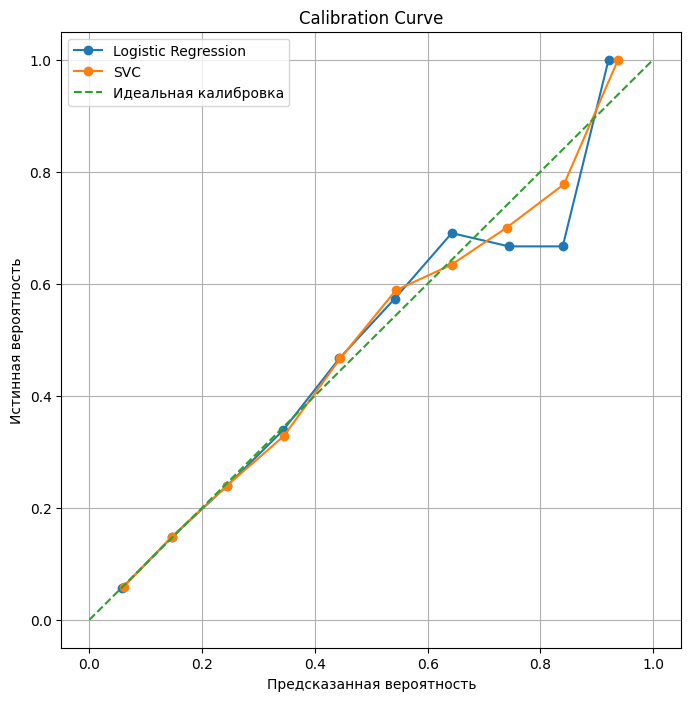

In [158]:
plot_calibration_curve(
    y_train, 
    [y_proba_logreg_best_filtered, y_proba_svc_best_filtered],
    names=['Logistic Regression', 'SVC'],
    n_bins=10
)

Анализ:
- для двух наилучших моделей необходимо провести калибровку веротяностей.
- в диапазоне 0.6-1 наблюдается отличие от идеального значения калибровки для обеих моделей

#### 9.2 Применение методов калибровки

In [159]:
def get_calibrated_model(
    model,
    X_train,
    y_train,
    X_calib,
    y_calib,
    method: str = 'isotonic',
):
    preprocessor = create_preprocessing_pipeline(with_filtering=True)
    preprocessor.fit(X_train, y_train)

    X_train_prep = preprocessor.transform(X_train)
    X_calib_prep = preprocessor.transform(X_calib)

    base_model = clone(model)
    base_model.fit(X_train_prep, y_train)

    calibrated_model = CalibratedClassifierCV(
        estimator=FrozenEstimator(base_model),
        method=method,
        cv=3,
        n_jobs=-1
    )
    calibrated_model.fit(X_calib_prep, y_calib)

    return preprocessor, base_model, calibrated_model



In [160]:
# Обучение с калибровкой 
svc_best = get_best_svc(top_svc_models, probability=True)

svc_preprocessor, svc_base, svc_calibrated = get_calibrated_model(
    model=svc_best,
    X_train=X_train,
    y_train=y_train,
    X_calib=X_calib,
    y_calib=y_calib,
    method='isotonic',
)

In [161]:
X_test_prep = svc_preprocessor.transform(X_test)

y_test_proba_svc_calibrated = svc_calibrated.predict_proba(X_test_prep)[:, 1]
y_test_proba_svc = svc_base.predict_proba(X_test_prep)[:, 1]


In [162]:
logreg_best = get_best_logreg(top_logreg_models)
logreg_preprocessor, logreg_base, logreg_calibrated = get_calibrated_model(
    model=logreg_best,
    X_train=X_train,
    y_train=y_train,
    X_calib=X_calib,
    y_calib=y_calib,
    method='isotonic',
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

In [163]:
X_test_prep = logreg_preprocessor.transform(X_test)

y_test_proba_logreg_calibrated = logreg_calibrated.predict_proba(X_test_prep)[:, 1]
y_test_proba_logreg = logreg_base.predict_proba(X_test_prep)[:, 1]

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

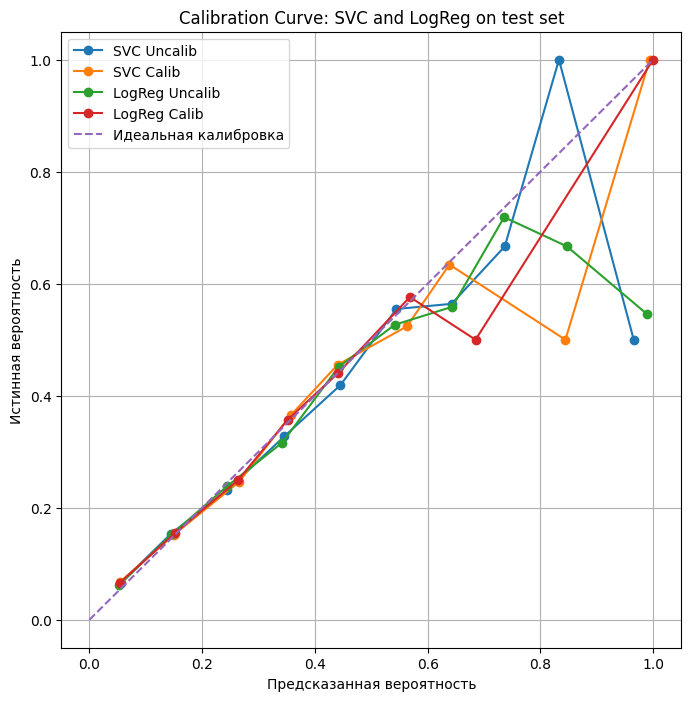

In [164]:
plot_calibration_curve(
    y_test,
    [y_test_proba_svc, y_test_proba_svc_calibrated, y_test_proba_logreg, y_test_proba_logreg_calibrated],
    names=['SVC Uncalib', 'SVC Calib', 'LogReg Uncalib', 'LogReg Calib'],
    n_bins=10,
    title='Calibration Curve: SVC and LogReg on test set'
)

## 11. Оценка качества калибровки

In [165]:
def calculate_ece(y_true, y_prob, n_bins=10):
    """Расчет ECE (Expected Calibration Error)"""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    n = len(y_true)
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_size = np.sum(mask)

            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            ece += np.abs(bin_conf - bin_acc) * bin_size
    return ece / n

def calculate_mce(y_true, y_prob, n_bins=10):
    """Расчет MCE (Maximum Calibration Error)"""
    bins = np.linspace(0, 1, n_bins + 1)
    max_error = 0
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            diff = np.abs(bin_conf - bin_acc)
            max_error = np.max([max_error, diff])
    return max_error


In [166]:
def get_final_metrics(y_test, model_probabilities, sort_by=['brier_score', 'ece', 'mce']):
    calibration_metrics = []
    for model_name, y_proba in model_probabilities.items():
        ece = calculate_ece(y_test, y_proba, n_bins=10)
        mce = calculate_mce(y_test, y_proba, n_bins=10)
        pr_auc = average_precision_score(y_test, y_proba)
        calibration_metrics.append({
            'model': model_name,
            'brier_score': brier_score_loss(y_test, y_proba),
            'ece': ece,
            'mce': mce,
            'pr_auc': pr_auc
        })

    return (
        pd.DataFrame(calibration_metrics)
        .sort_values(by=sort_by, ascending=True)
        .reset_index(drop=True)
    )

In [167]:
model_probabilities = {
    'SVC Uncalib': y_test_proba_svc,
    'SVC Calib': y_test_proba_svc_calibrated,
    'LogReg Uncalib': y_test_proba_logreg,
    'LogReg Calib': y_test_proba_logreg_calibrated
}
calibration_metrics_df = get_final_metrics(y_test, model_probabilities)
calibration_metrics_df

,model,brier_score,ece,mce,pr_auc
0,SVC Uncalib,0.128243,0.012647,0.465668,0.363835
1,LogReg Uncalib,0.128243,0.010212,0.444099,0.363040
2,LogReg Calib,0.128270,0.009249,0.185003,0.348333
3,SVC Calib,0.128273,0.010544,0.344426,0.352126


Анализ:
- калибровка модели SVC позволила снизить максимальную ошибку MCE и среднюю ошибку ECE. 
- на метрики MCE, ECE калибровка повлияла неодназначно: максимальная MCE ошибка возросла, средний показатель ECE при этом снизился
- оценка Бриера после процедуры калибровки практически не изменилась (менее 1%)
- на ключевую метрику PR-AUC калибровка повлияла негативно: у калиброванных моделей метрика снизилась
- после калибровки brier_score моделей SVC и LogReg практически равны, но по pr_auc SVC Calib лучше

## 12. Финальный отчёт и выводы

### 12.1 Сводная таблица результатов

In [168]:
# базовая модель
dummy_classifier = DummyClassifier(random_state=RANDOM_SEED)
pipeline_dummy = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', dummy_model)
])
pipeline_dummy.fit(X_train, y_train)

y_proba_dummy = pipeline_dummy.predict_proba(X_test)[:, 1]

In [169]:
X_test_logreg_prep = logreg_preprocessor.transform(X_test)
X_test_svc_prep = svc_preprocessor.transform(X_test)

final_model_probabilities = {
    'Dummy': pipeline_dummy.predict_proba(X_test)[:, 1],
    'LogReg Uncalib': logreg_base.predict_proba(X_test_logreg_prep)[:, 1],
    'LogReg Calib': logreg_calibrated.predict_proba(X_test_logreg_prep)[:, 1],
    'SVC Uncalib': svc_base.predict_proba(X_test_svc_prep)[:, 1],
    'SVC Calib': svc_calibrated.predict_proba(X_test_svc_prep)[:, 1],
}

result_rows = []

for name, y_proba in final_model_probabilities.items():
    result_rows.append({
        'model': name,
        'brier_score': brier_score_loss(y_test, y_proba),
        'ece': calculate_ece(y_test, y_proba, n_bins=10),
        'mce': calculate_mce(y_test, y_proba, n_bins=10),
        'pr_auc': average_precision_score(y_test, y_proba),
    })

result_df = (
    pd.DataFrame(result_rows)
    .sort_values(by='pr_auc', ascending=False)
    .reset_index(drop=True)
)

result_df


/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

,model,brier_score,ece,mce,pr_auc
0,SVC Uncalib,0.128243,0.012647,0.465668,0.363835
1,LogReg Uncalib,0.128243,0.010212,0.444099,0.363040
2,SVC Calib,0.128273,0.010544,0.344426,0.352126
3,LogReg Calib,0.128270,0.009249,0.185003,0.348333
4,Dummy,0.142482,0.000037,0.000037,0.172100


In [170]:
def get_top_important_features_permutation(
    pipeline: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    top_n: int = 10,
    scoring: str = 'average_precision',
    n_repeats: int = 3,
    random_state: int = RANDOM_SEED,
) -> pd.DataFrame:
    """Наиболее важные признаки для модели"""
    preprocessor = pipeline.named_steps['prep']
    feature_names = preprocessor.get_feature_names_out()
    X_transformed = preprocessor.transform(X)

    result = permutation_importance(
        pipeline.named_steps['model'],
        X_transformed,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    importance_df = (
        pd.DataFrame({
            'feature': feature_names,
            'importance_mean': result.importances_mean,
            'importance_std': result.importances_std
        })
        .sort_values('importance_mean', ascending=False)
        .reset_index(drop=True)
    )

    return importance_df.head(top_n)

In [171]:
# лучшая модель среди откалиброванных 
pipeline_best = Pipeline([
    ('prep', svc_preprocessor),
    ('model', svc_calibrated)
])

top_important_feat = get_top_important_features_permutation(pipeline_best, X_train, y_train, top_n=10)
top_important_feat

,feature,importance_mean,importance_std
0,cat_target__app_id,0.078119,0.002694
1,num_continues_norm_dist__ml_feature_9,0.061798,0.001294
2,num_continues_norm_dist__ml_feature_10,0.048570,0.003362
3,cat_one_hot__C18_2,0.019001,0.000548
4,num_continues_other_dist__ml_feature_8,0.016838,0.001003
5,num_continues_other_dist__ml_feature_6,0.015988,0.001445
6,special_outliers__C16,0.014927,0.000202
7,num_continues_norm_dist__ml_feature_5,0.011753,0.000395
8,special__C14,0.003015,0.000865
9,cat_one_hot__C18_1,0.002783,0.000584


In [172]:
top_important_feat_names = top_important_feat['feature'].map(get_original_feature_name) # топ важнейших признаков  
top_important_feat_names

0           app_id
1     ml_feature_9
2    ml_feature_10
3              C18
4     ml_feature_8
5     ml_feature_6
6              C16
7     ml_feature_5
8              C14
9              C18
Name: feature, dtype: object

### 12.2 Выводы

Ответьте на вопросы:
- Качество разработанной модели существенно лучше baseline по ключевым метрикам: для лучшей модели SVC метрика PR-AUC = 0.35, что в 2 раза превосходит показатель Dummy модели = 0.17. Оценка Бриера также улучшена: 0.12 < 0.14 

Признаки, влияющие больше всего на вероятность отклика:
- app_id, C18, C16, C14, C18 - это характеристики рекламируемого приложения, характеристики баннера/пользователя/аукциона. Важными для модели оказались сгенерированный ML признаки: ml_feature_9, ml_feature_10, ml_feature_8, ml_feature_6, ml_feature_5  - попали в топ по значимости для итоговой модели.

Калибровка:
- модель хорошо откалибрована. В результате процедуры калибровки метрики MCE и ECE уменьшены на 20-25%

Итоговая откалиброванная модель готова к использованию в продакшене



### 12.3 Рекомендации

Среди дальнейших улучшений можно отметить генерацию новых фичей, позволяющих уследить нелинейные зависимости. Возможно, стоит в будущем поробовать более сложные нелинейные модели классификации. В настоящий момент итоговая метрика Average Precision находится на достаточно низком уровне. Линейные модели не позволяют уверенно отделить два класса друг от друга. Ядровый трюк в SVC не дал ощутимых результатов. 

## 13. Сохранение модели для продакшена

Сохранение:

In [173]:
joblib.dump(pipeline_best, 'pipeline_best.joblib')

['pipeline_best.joblib']

Проверка:

In [174]:
loaded_pipeline = joblib.load('pipeline_best.joblib')

y_pred_proba = loaded_pipeline.predict_proba(X_test)[:, 1]
y_pred = loaded_pipeline.predict(X_test)

In [175]:
y_pred_proba

array([0.36821705, 0.26325088, 0.11282051, ..., 0.26325088, 0.13247863,
       0.29098361])